# **GAMING ENGAGEMENT LEVEL PREDICTION**

### **Project Overview**

This project develops a supervised multi-class classification model to predict player engagement levels (Low, Medium, High) using behavioral and gameplay features. 

**XGBoost** emerged as the best-performing model, evaluated using the **Macro F1-score** to ensure balanced performance across all engagement tiers. Behavioral intensity metrics — particularly **Sessions per Week** and **Average Session Duration** — were identified as the strongest drivers of engagement, while demographic variables showed limited predictive impact.

From a business perspective, the model enables **early detection of disengaged players**, supporting targeted retention strategies, personalization efforts, and optimized monetization initiatives.

### **Problem Statement**

Player engagement is a critical performance indicator in the gaming industry, directly influencing retention, lifetime value, and revenue growth.

The objective of this project is to build a predictive model that classifies players into engagement tiers based on behavioral gameplay data. By uncovering the patterns that differentiate highly engaged users from at-risk players, the model provides actionable insights to support data-driven decision-making and early intervention strategies.

### **Environment Setup**

In [1]:
# Warnings
import warnings
warnings.filterwarnings("ignore")

# Core Libraries
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Data Handling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# External Models
from xgboost import XGBClassifier

# Scikit-learn: Evaluation
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Utilities
from sklearn.base import clone

# Set random seed for reproducibility 
np.random.seed(42)

### **Data Loading**

In [2]:
# Load raw data and create a working copy
data_raw = pd.read_csv('../data/raw/online_gaming_behavior_insights.csv')
data = data_raw.copy()

### **Initial Data Inspection (Non-Graphical EDA)**

In [3]:
# first look
data.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
# shape
print("Dataset shape:", data.shape)

Dataset shape: (40034, 13)


In [5]:
# data types and nulls
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [6]:
# statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


In [7]:
duplicates = data.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [8]:
print("Unique Values per Column:")
data.nunique()

Unique Values per Column:


PlayerID                     40034
Age                             35
Gender                           2
Location                         4
GameGenre                        5
PlayTimeHours                40034
InGamePurchases                  2
GameDifficulty                   3
SessionsPerWeek                 20
AvgSessionDurationMinutes      170
PlayerLevel                     99
AchievementsUnlocked            50
EngagementLevel                  3
dtype: int64

In [9]:
print("Missing Values per column:")
data.isna().sum()

Missing Values per column:


PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [10]:
# target variable distribution
data['EngagementLevel'].value_counts(normalize=True)

EngagementLevel
Medium    0.483939
High      0.258181
Low       0.257881
Name: proportion, dtype: float64

### **Exploratory Data Analysis (Graphical EDA)**

In [11]:
# Global Plot Styling Configuration

plt.rcParams.update({
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',

    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,

    'axes.labelsize': 12,

    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    'axes.grid': False
})

#### **1. Univariate Analysis**


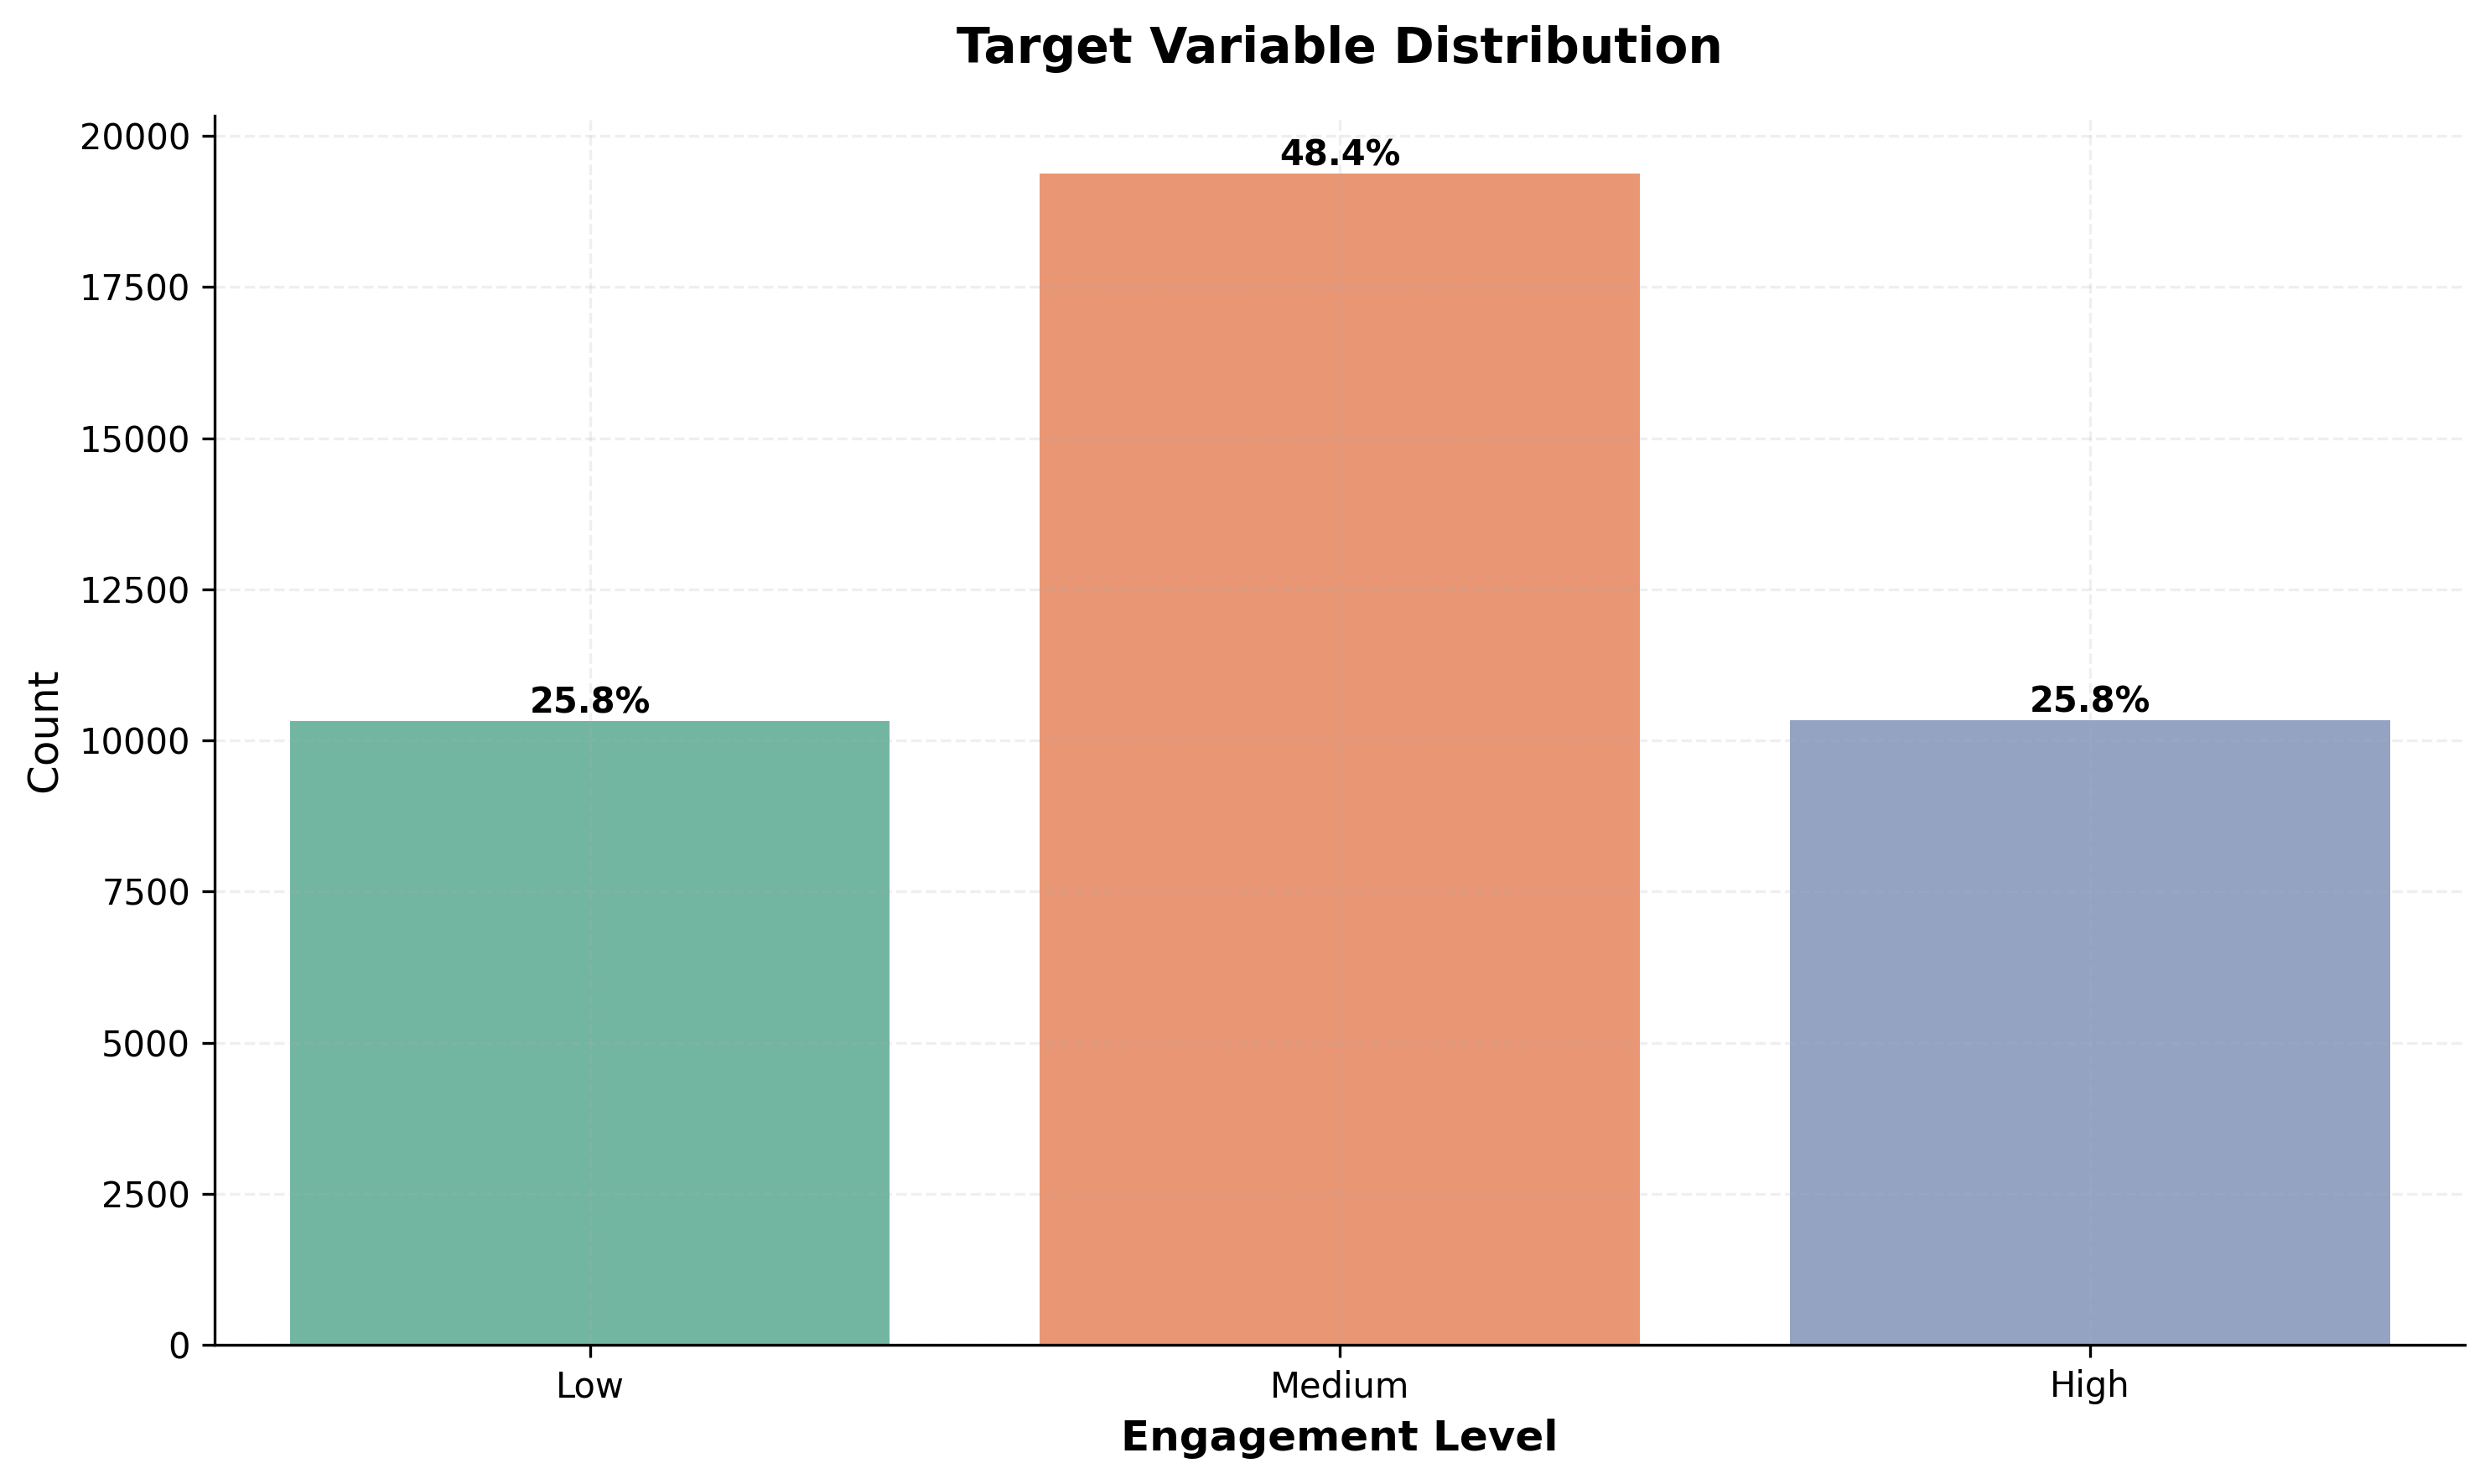

In [12]:
# TARGET VARIABLE DISTRIBUTION

# setup the figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(x='EngagementLevel',
              data=data,
              palette='Set2',
              order=['Low', 'Medium', 'High'])

# add percentage labels 
for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(data):.1f}%'
    ax.annotate(text=percentage, xy= (p.get_x() + p.get_width() /2, p.get_height() + 5), 
                ha='center', va='bottom', weight='bold')
    
# title and labels
ax.set_title('Target Variable Distribution')
ax.set_xlabel('Engagement Level', weight='semibold')
ax.set_ylabel('Count')

# styling
plt.grid(alpha=0.2, linestyle='--')
sns.despine()

# adjust layout 
plt.tight_layout()

# save image  
plt.savefig('../reports/figures/eda/target_variable_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**TARGET VARIABLE DISTRIBUTION ANALYSIS** 

- The dataset shows a mild majority-class dominance, with the Medium engagement level (48.4%) being larger than both the Low (25.8%) and High (25.8%) groups. 

- This pattern is typical in gaming behavior data, where most players fall into an average engagement category. 

- To prevent the model from favoring the majority class, evaluation will emphasize the Macro-averaged F1-score and Confusion Matrix rather than relying solely on Accuracy.

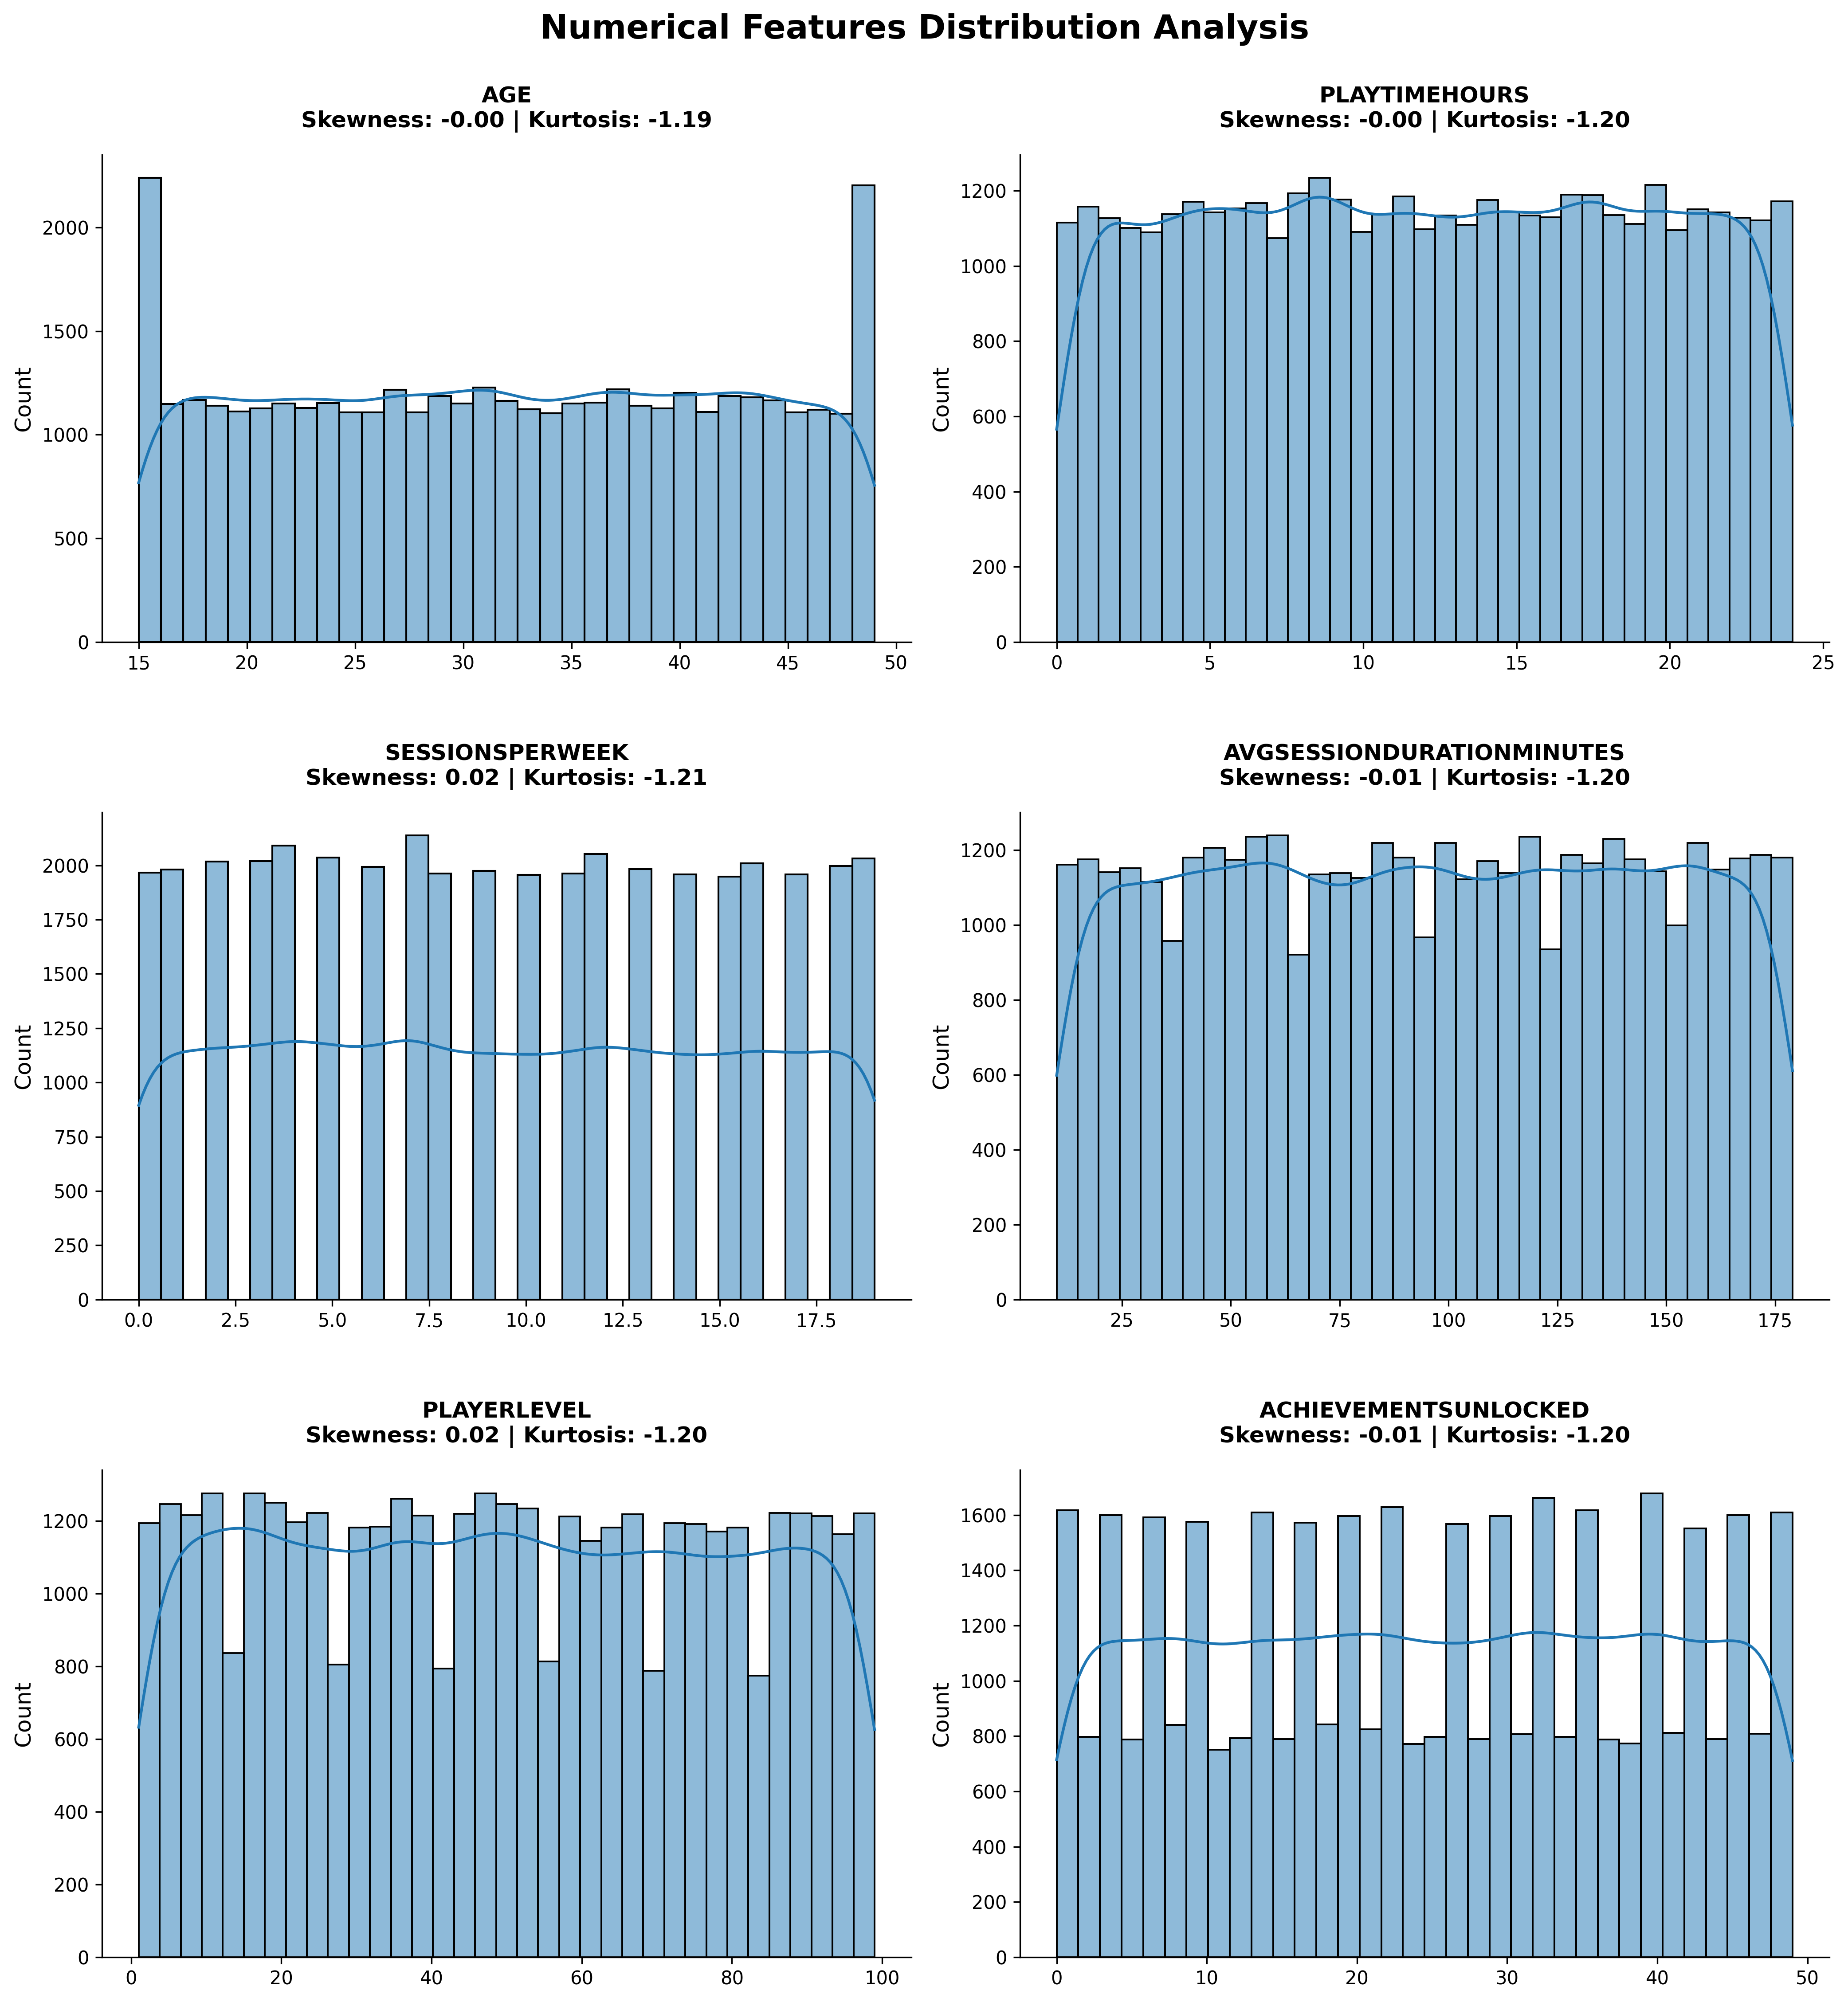

In [13]:
# NUMERICAL FEATURES DISTRIBUTION

# identify numerical columns (excluding IDs and binary features)
num_cols = [
    c for c in data.select_dtypes(include=['int64', 'float64']).columns
    if 'ID' not in c.upper() and data[c].nunique() > 2]

rows = (len(num_cols) + 1) // 2
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(14, 5 * rows))
fig.suptitle('Numerical Features Distribution Analysis', fontsize=18, weight='bold', y=1)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    # drop NaNs to ensure skewness and kurtosis are computed on valid observations
    clean_data = data[col].dropna()    
    skew = clean_data.skew()
    kurt = clean_data.kurtosis()
    
    # show KDE only for high-cardinality (continuous-like) features
    show_kde = data[col].nunique() > 10

    sns.histplot(data[col], kde=show_kde, ax=axes[i], edgecolor='black')
    axes[i].set_title(f"{col.upper()}\nSkewness: {skew:.2f} | Kurtosis: {kurt:.2f}", 
                      fontsize=12, weight='semibold')
    axes[i].set_xlabel('')

# adjust layout 
plt.tight_layout()
plt.subplots_adjust(hspace= 0.35)

# save image 
plt.savefig('../reports/figures/eda/numerical_features_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**NUMERICAL FEATURE DISTRIBUTION ANALYSIS**

- All numerical features (Age, PlayTimeHours, SessionsPerWeek, AvgSessionDurationMinutes, PlayerLevel, AchievementsUnlocked) exhibit **approximately symmetric distributions** within bounded ranges.

- **Skewness** values are close to 0, indicating mostly **balanced distributions**, while negative kurtosis (~ −1.20) suggests **flatter distributions** with fewer extreme values.

- Small spikes at boundaries (such as in Age) and step-like patterns in discrete features (PlayerLevel, AchievementsUnlocked) occur **due to limited ranges and whole-number values**, not unusual player behavior.

- Since the numerical features are symmetric and free of outliers, **no transformations are needed**. **Min–Max scaling** is preferred because the features are bounded and lack extreme values, allowing normalization without distorting their structure, and making explicit **outlier handling unnecessary**.

- ID columns and the binary feature (InGamePurchases) were excluded from this analysis, as distributional shape statistics are **not informative for identifier or binary variables**.

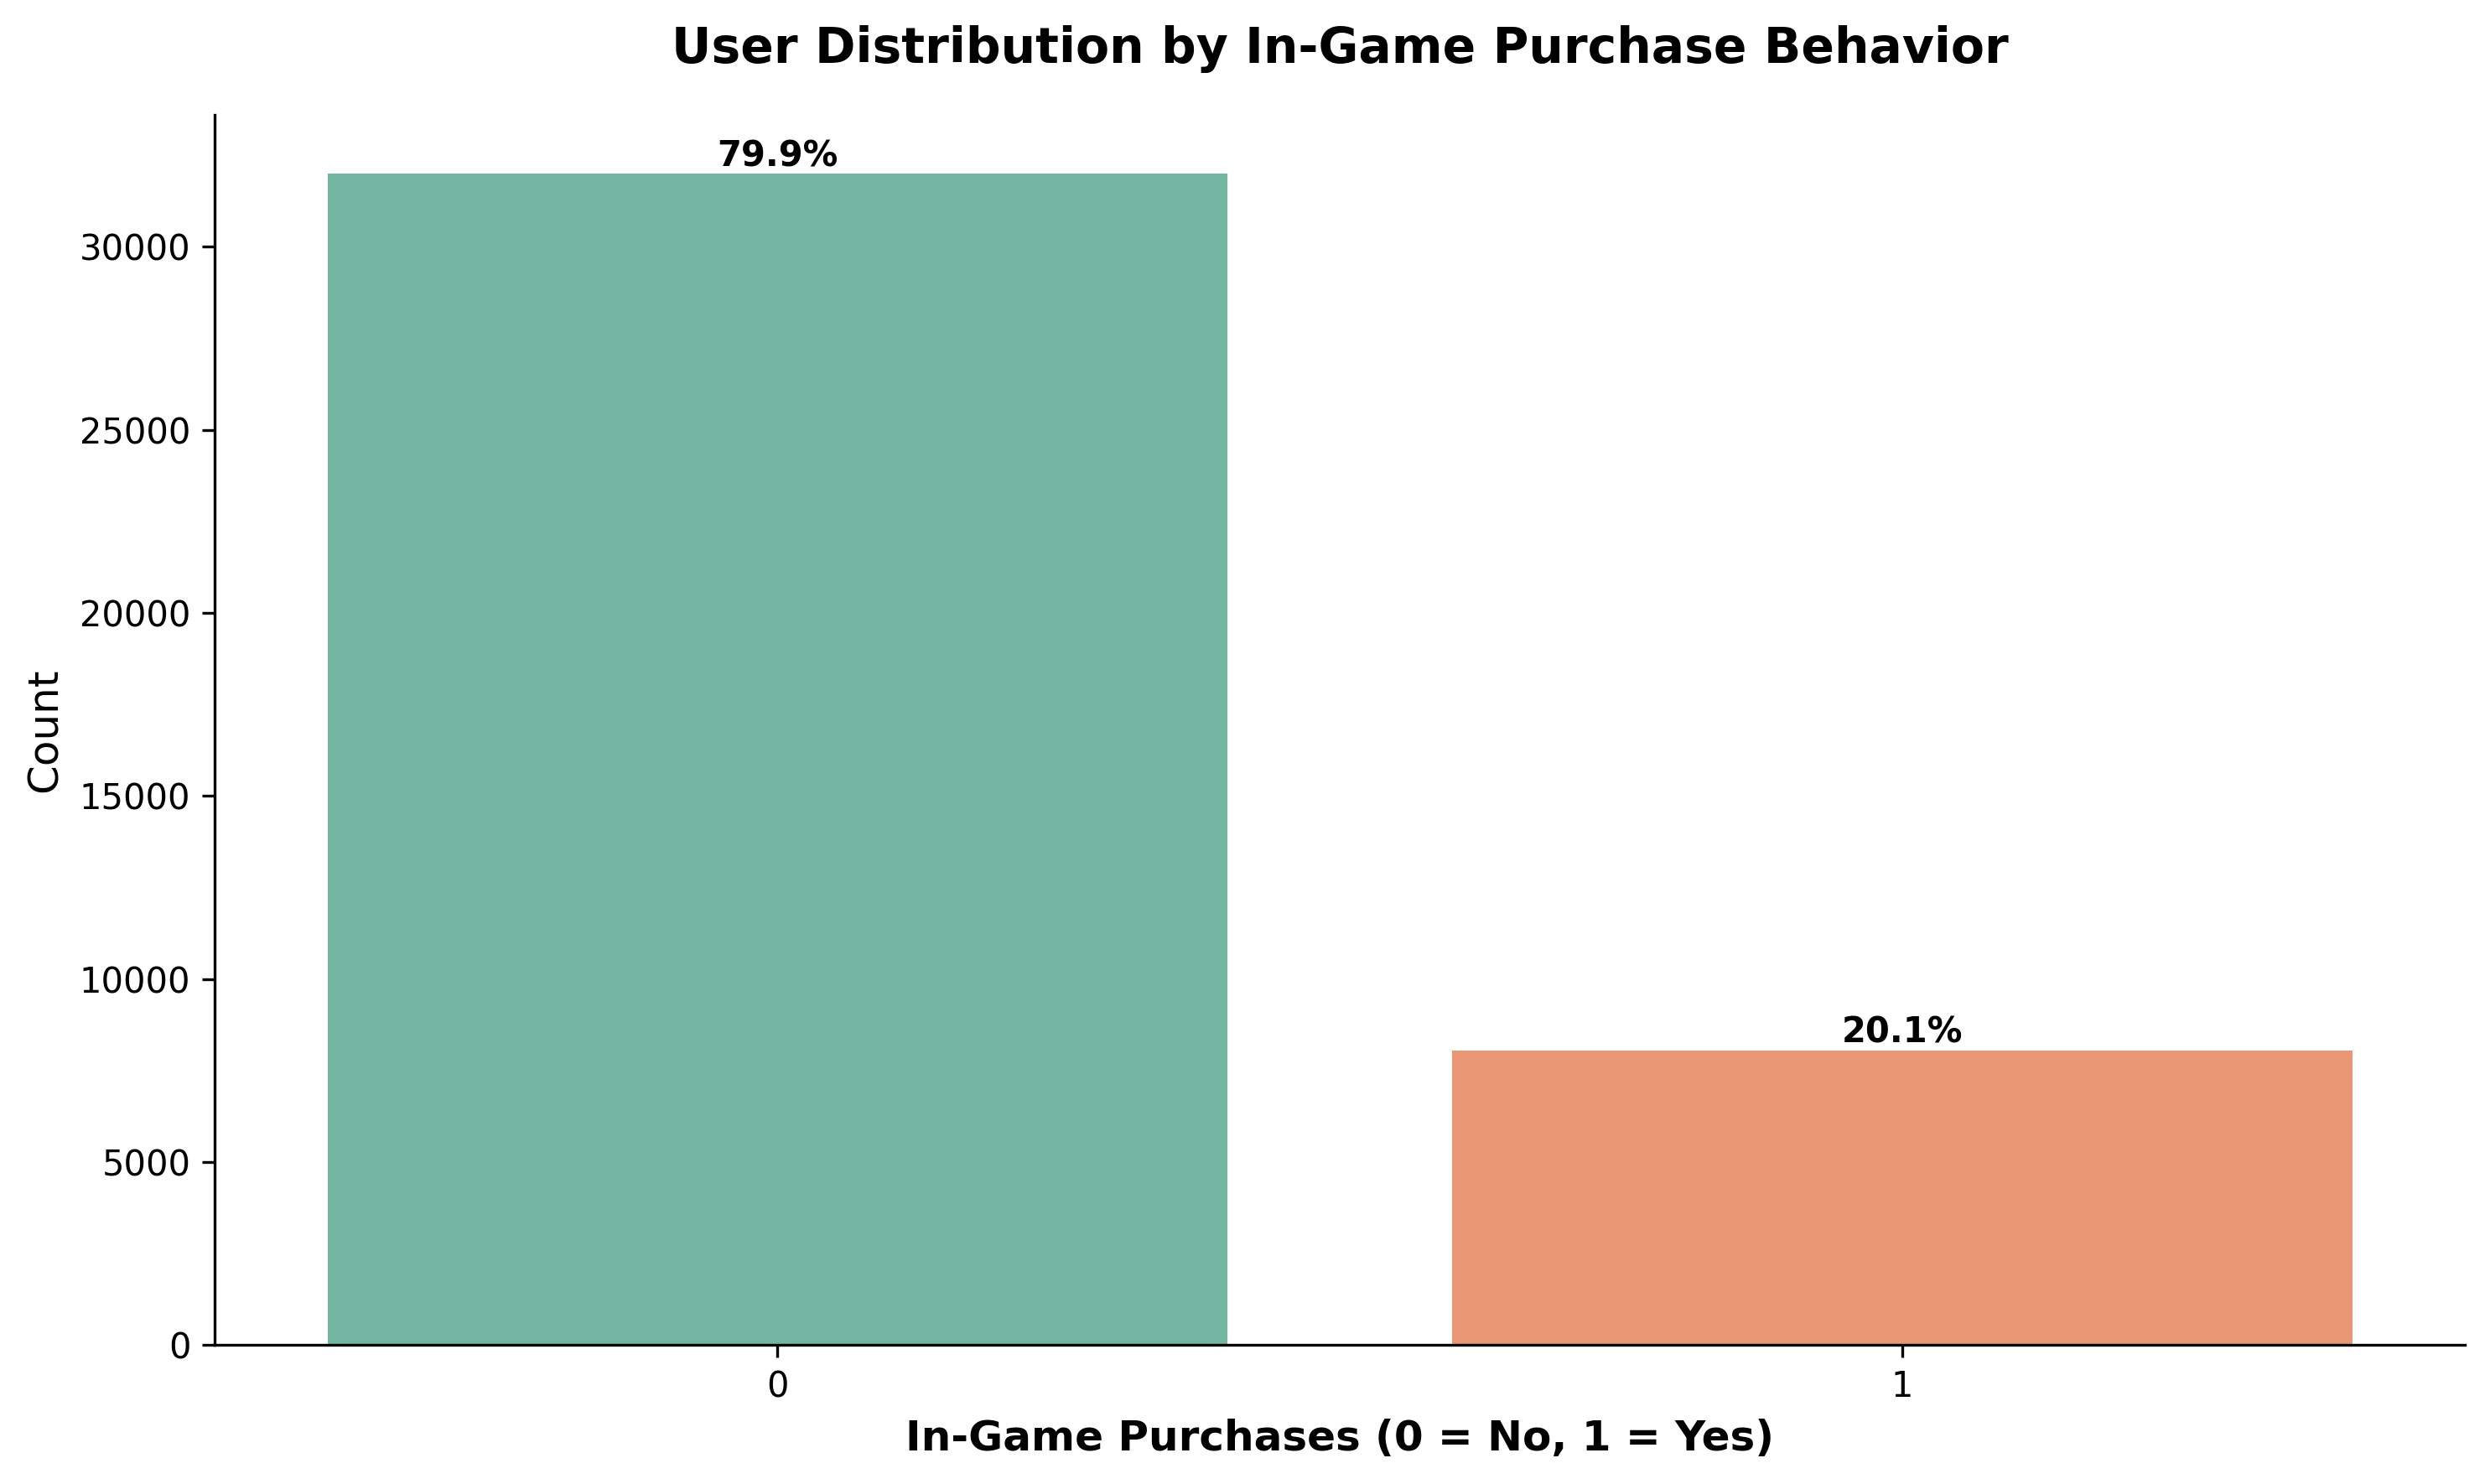

In [14]:
# BINARY FEATURE (InGamePurchases) FREQUENCY

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='InGamePurchases', data=data, palette='Set2')
  
# add percentage labels
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                ha='center', va='bottom', weight='bold')

plt.title('User Distribution by In-Game Purchase Behavior')
plt.xlabel('In-Game Purchases (0 = No, 1 = Yes)', weight='semibold')
plt.ylabel('Count')

# styling 
sns.despine()

# adjust layout 
plt.tight_layout()

# save image 
plt.savefig('../reports/figures/eda/in_game_purchases_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**IN-GAME PURCHASE PREVALENCE & CLASS BALANCE**

- The InGamePurchases feature is imbalanced, with **79.9% non-purchasers** and **20.1% purchasers**. This is common in games, where a small group of paying users drives most value. Although fewer, purchasers are strong indicators of high engagement. 

- Due to this imbalance, accuracy alone can be misleading, so **precision** and **recall** for the purchaser class (1) should be used during model evaluation.

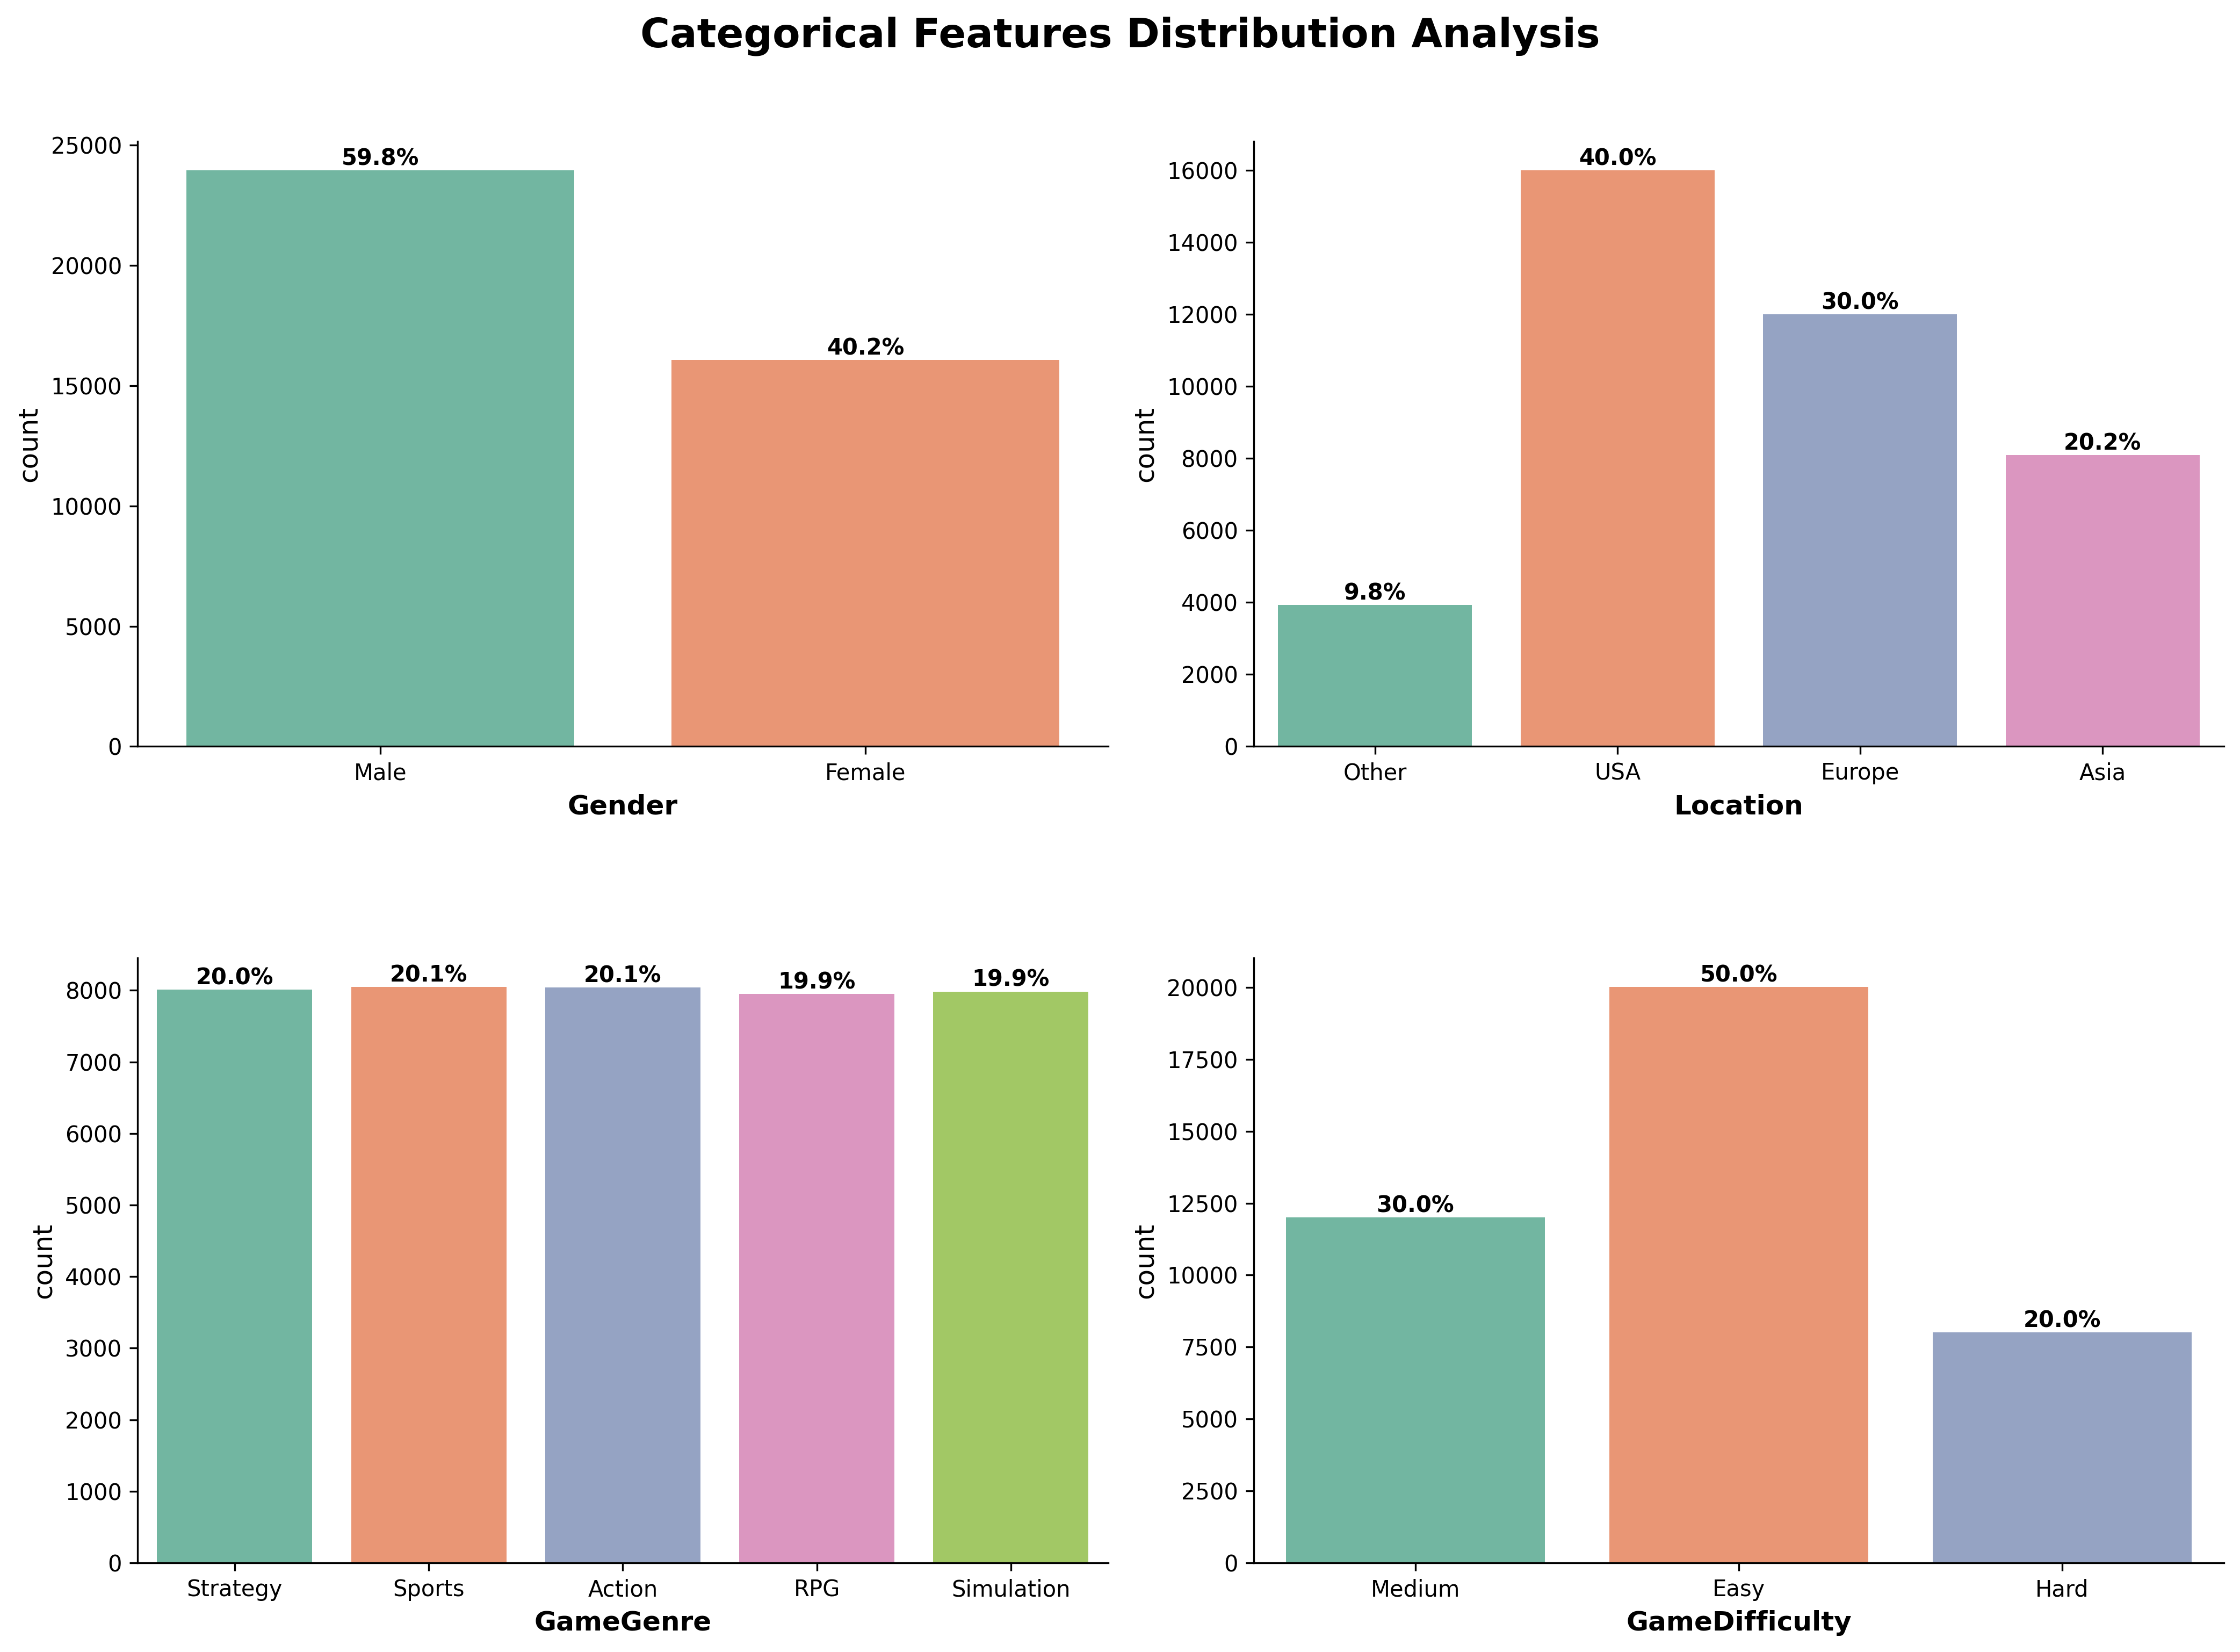

In [15]:
# CATEGORICAL FEATURES DISTRIBUTION

# identify categorical columns (excluding the target 'EngagementLevel')
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
# use a conditional check to avoid errors if the cell is run more than once
if 'EngagementLevel' in cat_cols:
    cat_cols.remove('EngagementLevel')

rows = math.ceil(len(cat_cols)/2)
fig,axes = plt.subplots(nrows=rows, ncols=2, figsize=(14, 5 *rows))
fig.suptitle('Categorical Features Distribution Analysis', fontsize=18, weight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=data, palette='Set2', ax=axes[i])
    axes[i].set_xlabel(col, weight='semibold')

    # add percentage labels
    total = len(data)
    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() +5),
                         ha='center', va='bottom', weight='semibold')

# adjust layout 
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)  # controls vertical gap

# save image 
plt.savefig('../reports/figures/eda/categorical_features_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()


**DISTRIBUTION ANALYSIS OF CATEGORICAL FEATURES**

This analysis examines key categorical variables to understand class balance and potential modeling bias.

* **Gender:**
  The dataset is **male-dominated (~60% Male, ~40% Female)**, indicating moderate imbalance. Gender bias should be checked during evaluation.

* **Location:**
  Users are mainly from **USA (~40%)**, followed by **Europe (~30%)** and **Asia (~20%)**. This shows that users are not evenly distributed across regions.

* **Game Genre:**
All genres are nearly evenly distributed (~20% each), indicating minimal imbalance. This reduces the risk of genre-driven bias and allows fair comparison of engagement across genres.

* **Game Difficulty:**
  Skewed toward **Easy (~50%)**, then **Medium (~30%)**, **Hard (~20%)**. Difficulty likely has a strong influence on engagement.

**Modeling Implications**

* Some imbalance exists (Gender, Location, Difficulty), but **no rare categories** are present.
* Use **stratified train-test splits** to preserve category proportions.
* Monitor model performance across **Gender and Location** groups.


The categorical features are informative and realistic. With proper encoding and stratification, they will **contribute effectively to predicting EngagementLevel**.


#### **2. Bivariate Analysis**

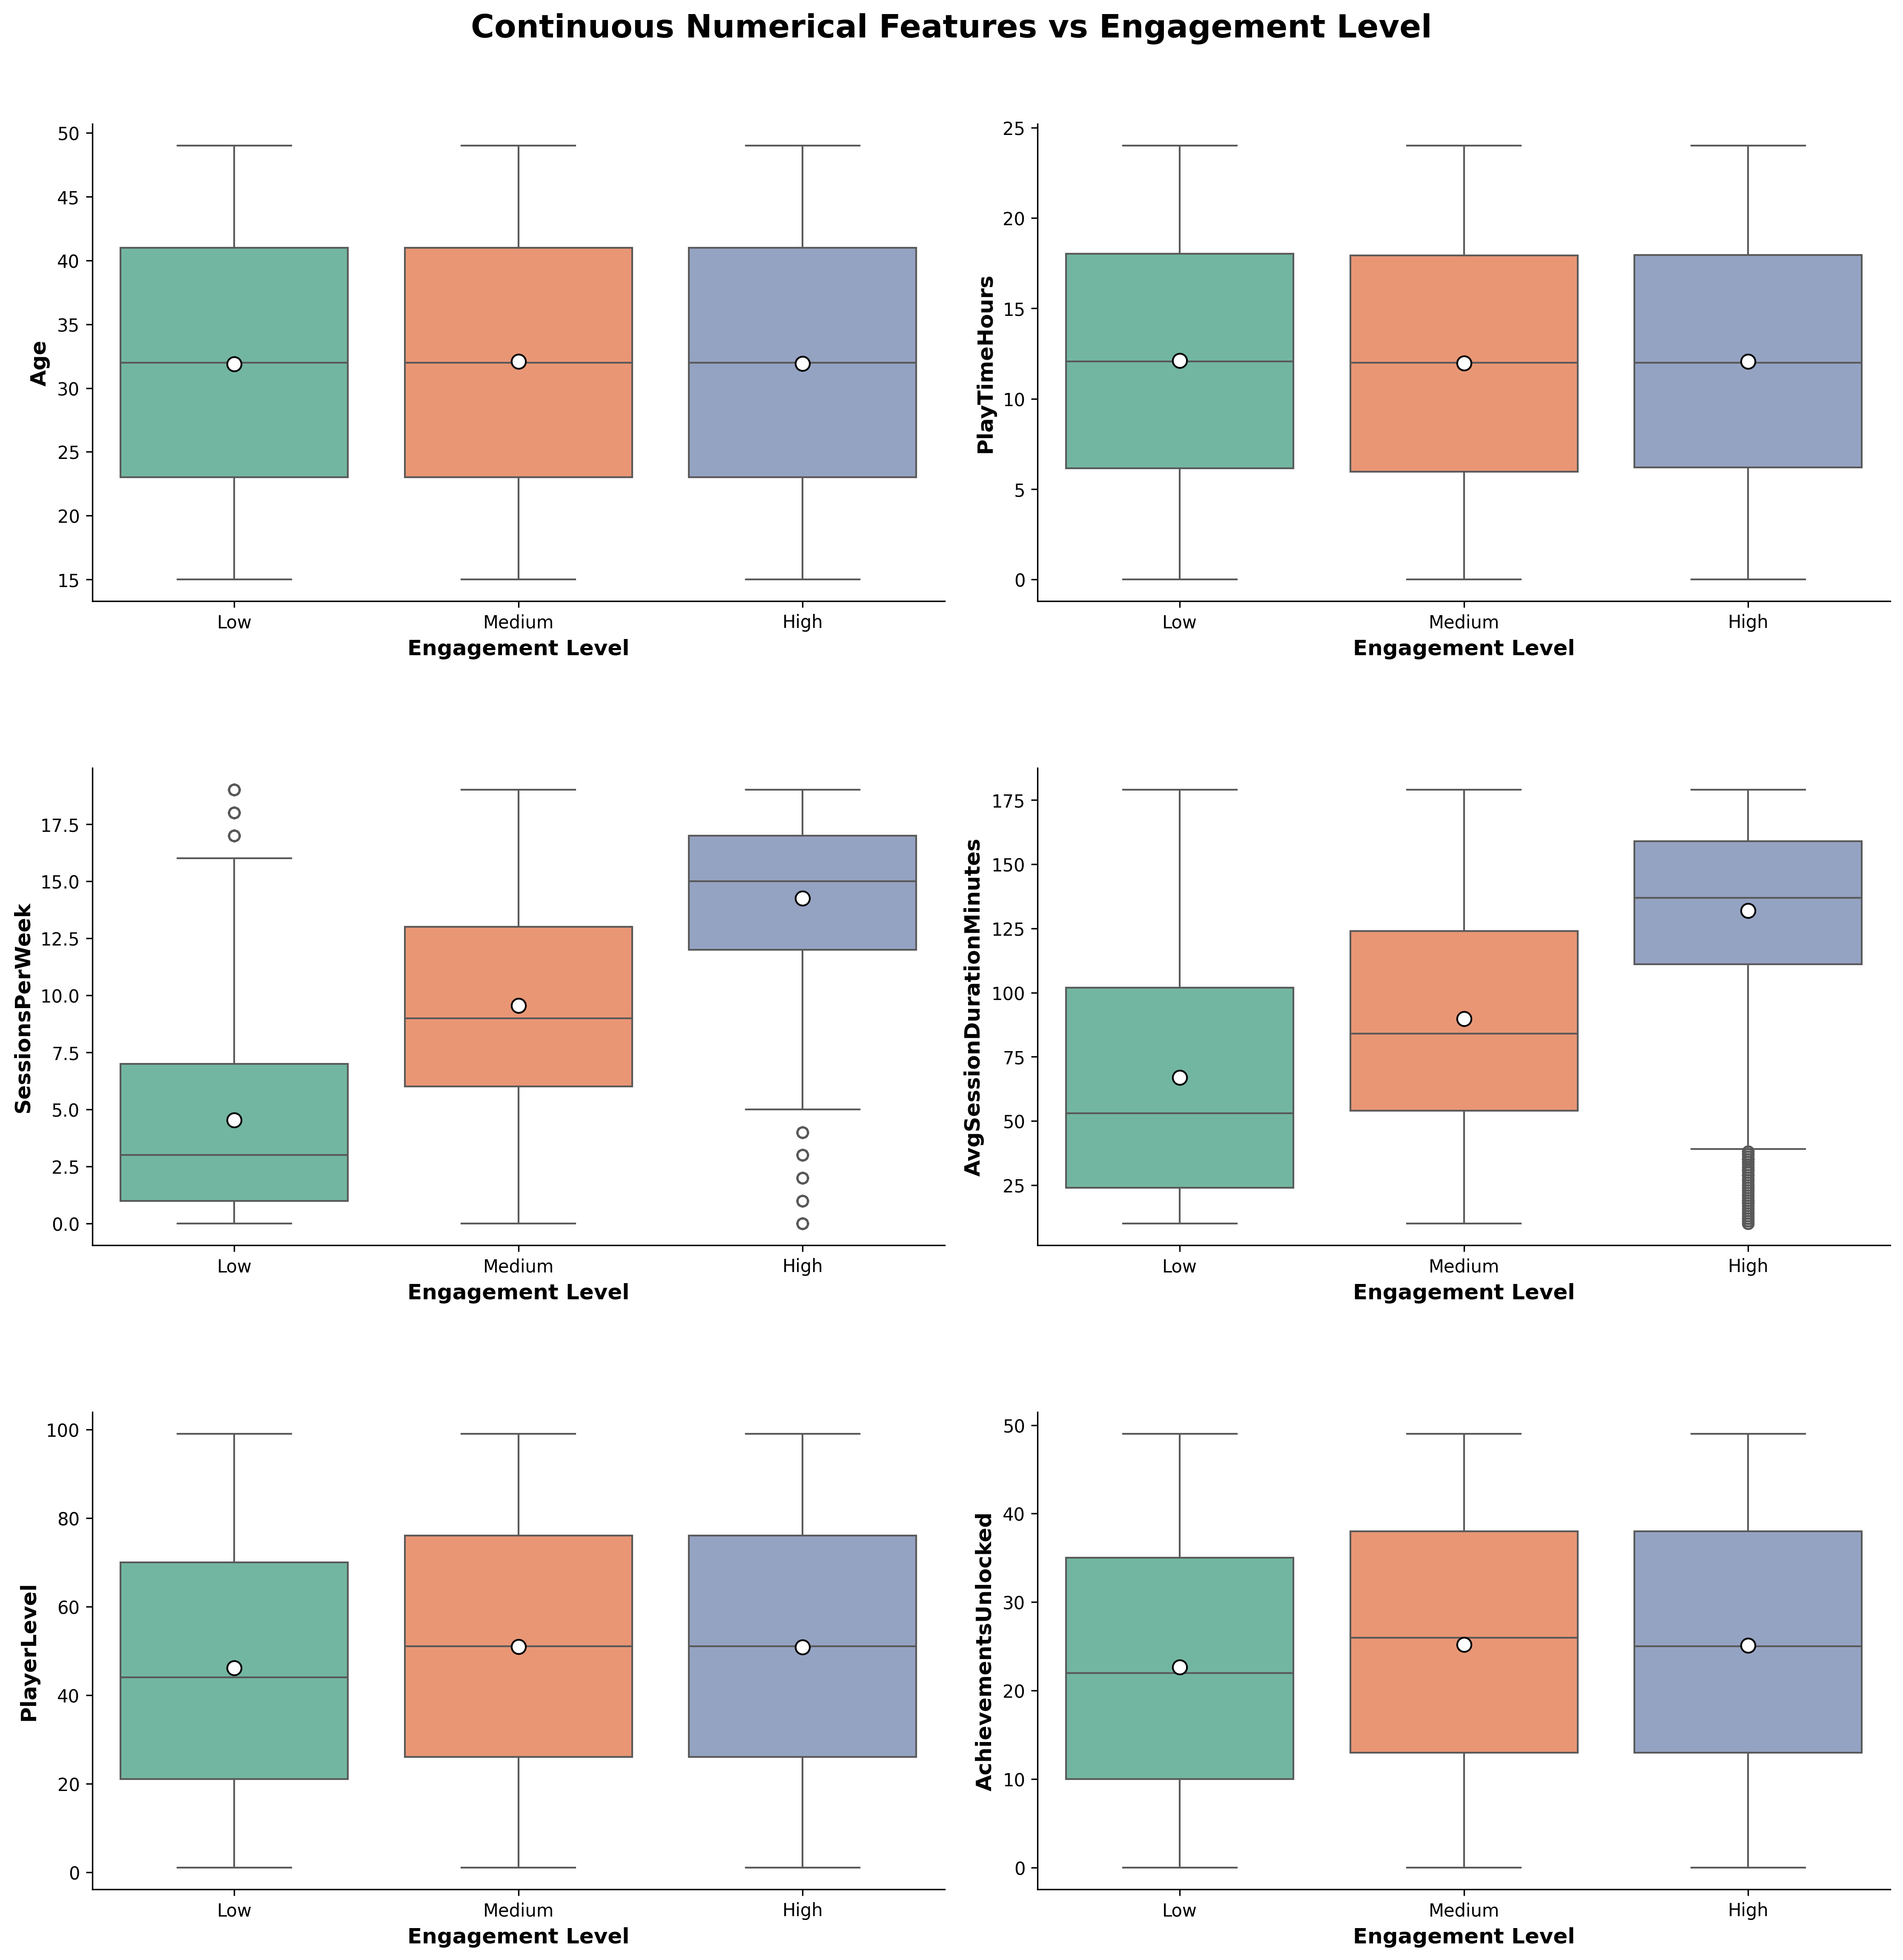

In [16]:
# CONTINUOUS NUMERICAL FEATURES VS TARGET VARIABLE

# num_cols defined earlier during univariate analysis
# num_cols = [
#    c for c in data.select_dtypes(include=['int64', 'float64']).columns
#    if 'ID' not in c.upper() and data[c].nunique() > 2]

# Calculate the number of rows needed for the grid (2 columns per row)
n_rows = math.ceil(len(num_cols) / 2)

fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, 5*n_rows))
fig.suptitle('Continuous Numerical Features vs Engagement Level', fontsize=18, weight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='EngagementLevel', y=col, data=data, ax=axes[i], 
                palette='Set2',
                order=['Low', 'Medium', 'High'],
                showmeans=True,  # This adds the mean
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    
    axes[i].set_xlabel('Engagement Level', weight='semibold')
    axes[i].set_ylabel(col, weight='semibold')

# adjust layot
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)

# save image 
plt.savefig('../reports/figures/eda/numerical_vs_engagement.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**Bivariate Analysis: Continuous Numerical Features vs Engagement Level**

This section analyzes the relationship between continuous numerical features and the target variable **Engagement Level (Low, Medium, High)** using boxplots with mean indicators. 

**1. Age vs Engagement Level**

- Age distributions are nearly identical across all engagement levels, with similar median and mean values.

- **Insight:** Age shows no meaningful relationship with engagement level and is not a strong predictor of user engagement.


**2. Play Time (Hours) vs Engagement Level**

- Play time distributions, including median, mean, and spread, are nearly identical across all engagement levels, with substantial overlap.

- **Insight:** Play time (hours) shows no meaningful relationship with engagement level and does not effectively differentiate engagement levels.


**3. Sessions per Week vs Engagement Level**

- A clear **increasing trend** is visible from Low to Medium to High engagement levels.

- High engagement users have much **higher median and mean** weekly sessions, while Low engagement users have significantly fewer sessions.

- **Insight:** Sessions per week is a **strong indicator of engagement**, with more frequent sessions strongly associated with higher engagement levels.


**4. Average Session Duration (Minutes) vs Engagement Level**

- **Median and mean** session duration increase consistently from Low to High engagement levels.

- High engagement users spend noticeably **longer per session** than Low engagement users.

- Despite the presence of outliers, the upward trend across engagement levels is clear.

- **Insight:** Average session duration shows a strong positive relationship with engagement, indicating sustained user involvement.


**5. Player Level vs Engagement Level**

- Medium and High engagement users tend to have **slightly higher player levels** than Low engagement users, with **substantial overlap across groups.**

- **Insight:** Player level shows a **moderate association** with engagement but does not clearly differentiate engagement levels.


**6. Achievements Unlocked vs Engagement Level**

- Median and mean achievements unlocked are **slightly higher** for Medium and High engagement users, with considerable overlap across groups.

- **Insight:** Achievements unlocked shows a **weak to moderate relationship** with engagement and does not clearly separate engagement levels.

**Overall Insight:**

 Users with **higher engagement play more frequently and spend longer time per session**, while factors like age and total playtime show little impact on engagement levels.

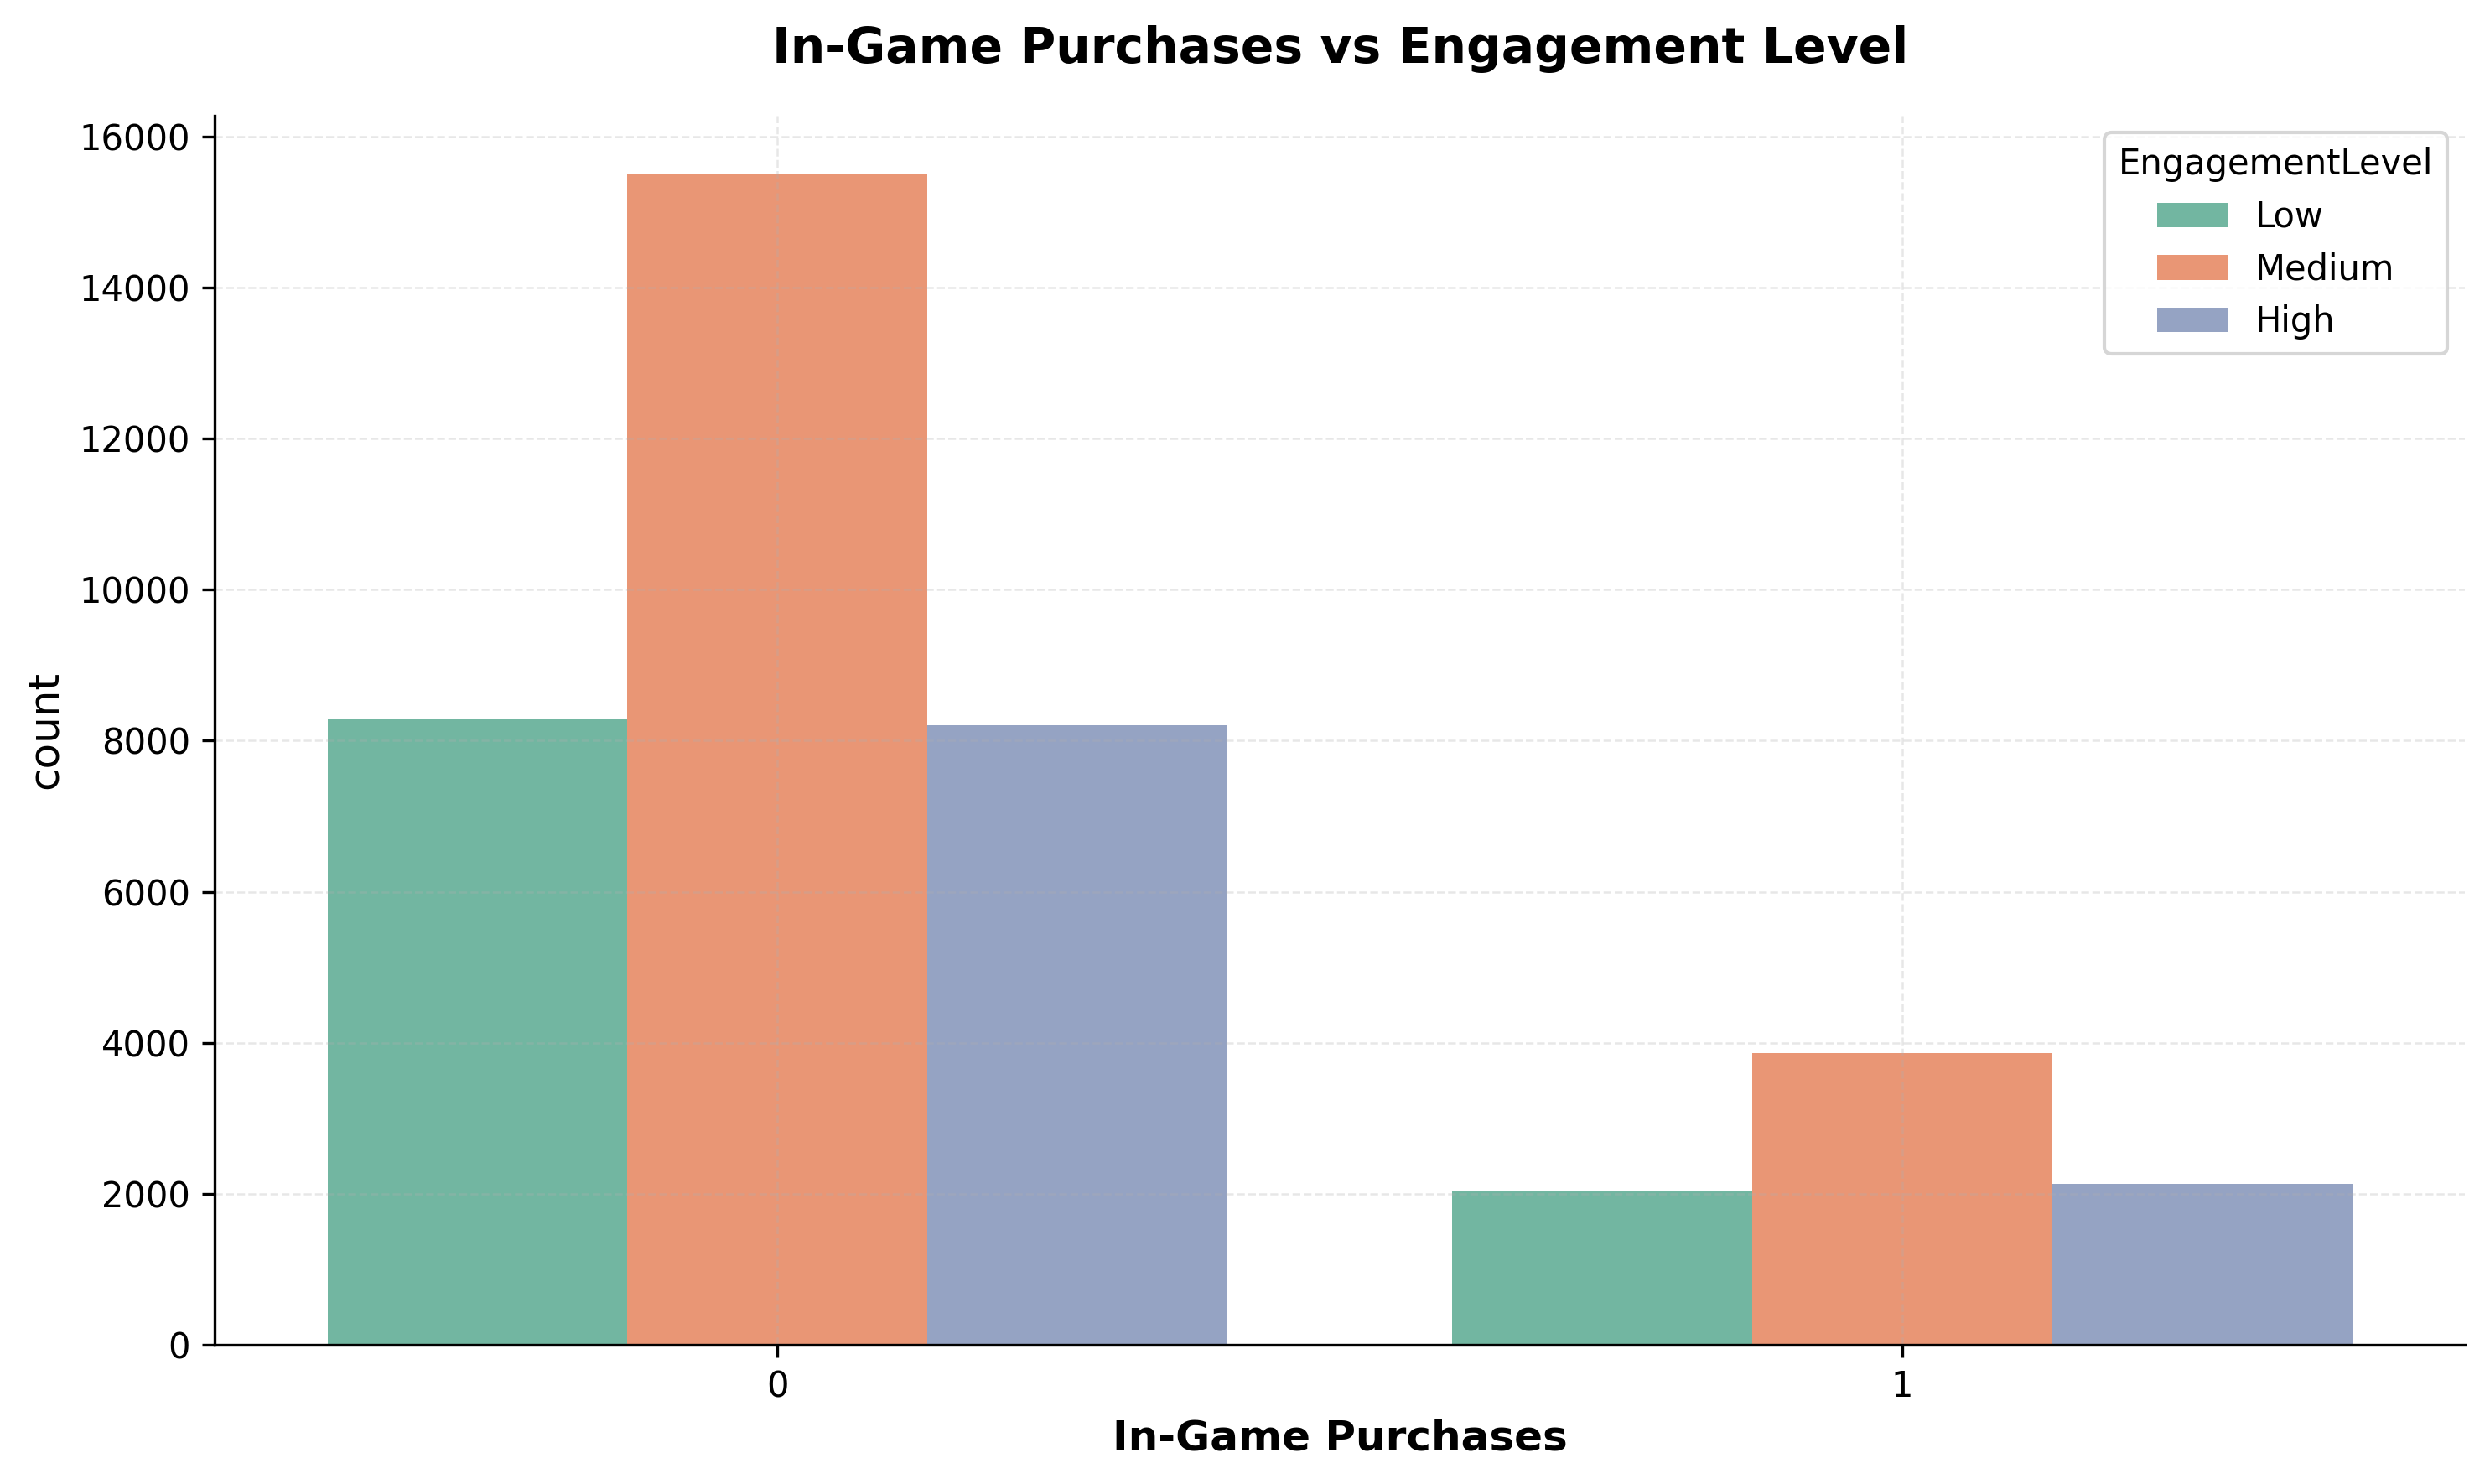

In [17]:
# IN-GAME PURCHASES VS TARGET VARIABLE (BIVARIATE)

plt.figure(figsize=(10, 6))
sns.countplot(x='InGamePurchases', data=data, hue='EngagementLevel',
              hue_order=['Low', 'Medium', 'High'], palette='Set2')

plt.title('In-Game Purchases vs Engagement Level')
plt.xlabel('In-Game Purchases', weight='bold')

plt.grid(linestyle='--', linewidth= 0.6, alpha= 0.3)

# adjust layot 
plt.tight_layout()
sns.despine()

# save image 
plt.savefig('../reports/figures/eda/in_game_purchases_vs_engagement.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**Bivariate Analysis: In-Game Purchases vs Engagement Level**

* **Medium engagement dominates** for both purchasers (1) and non-purchasers (0).
* Engagement patterns are similar across both groups, making in-game purchases a **weak predictor** on their own.

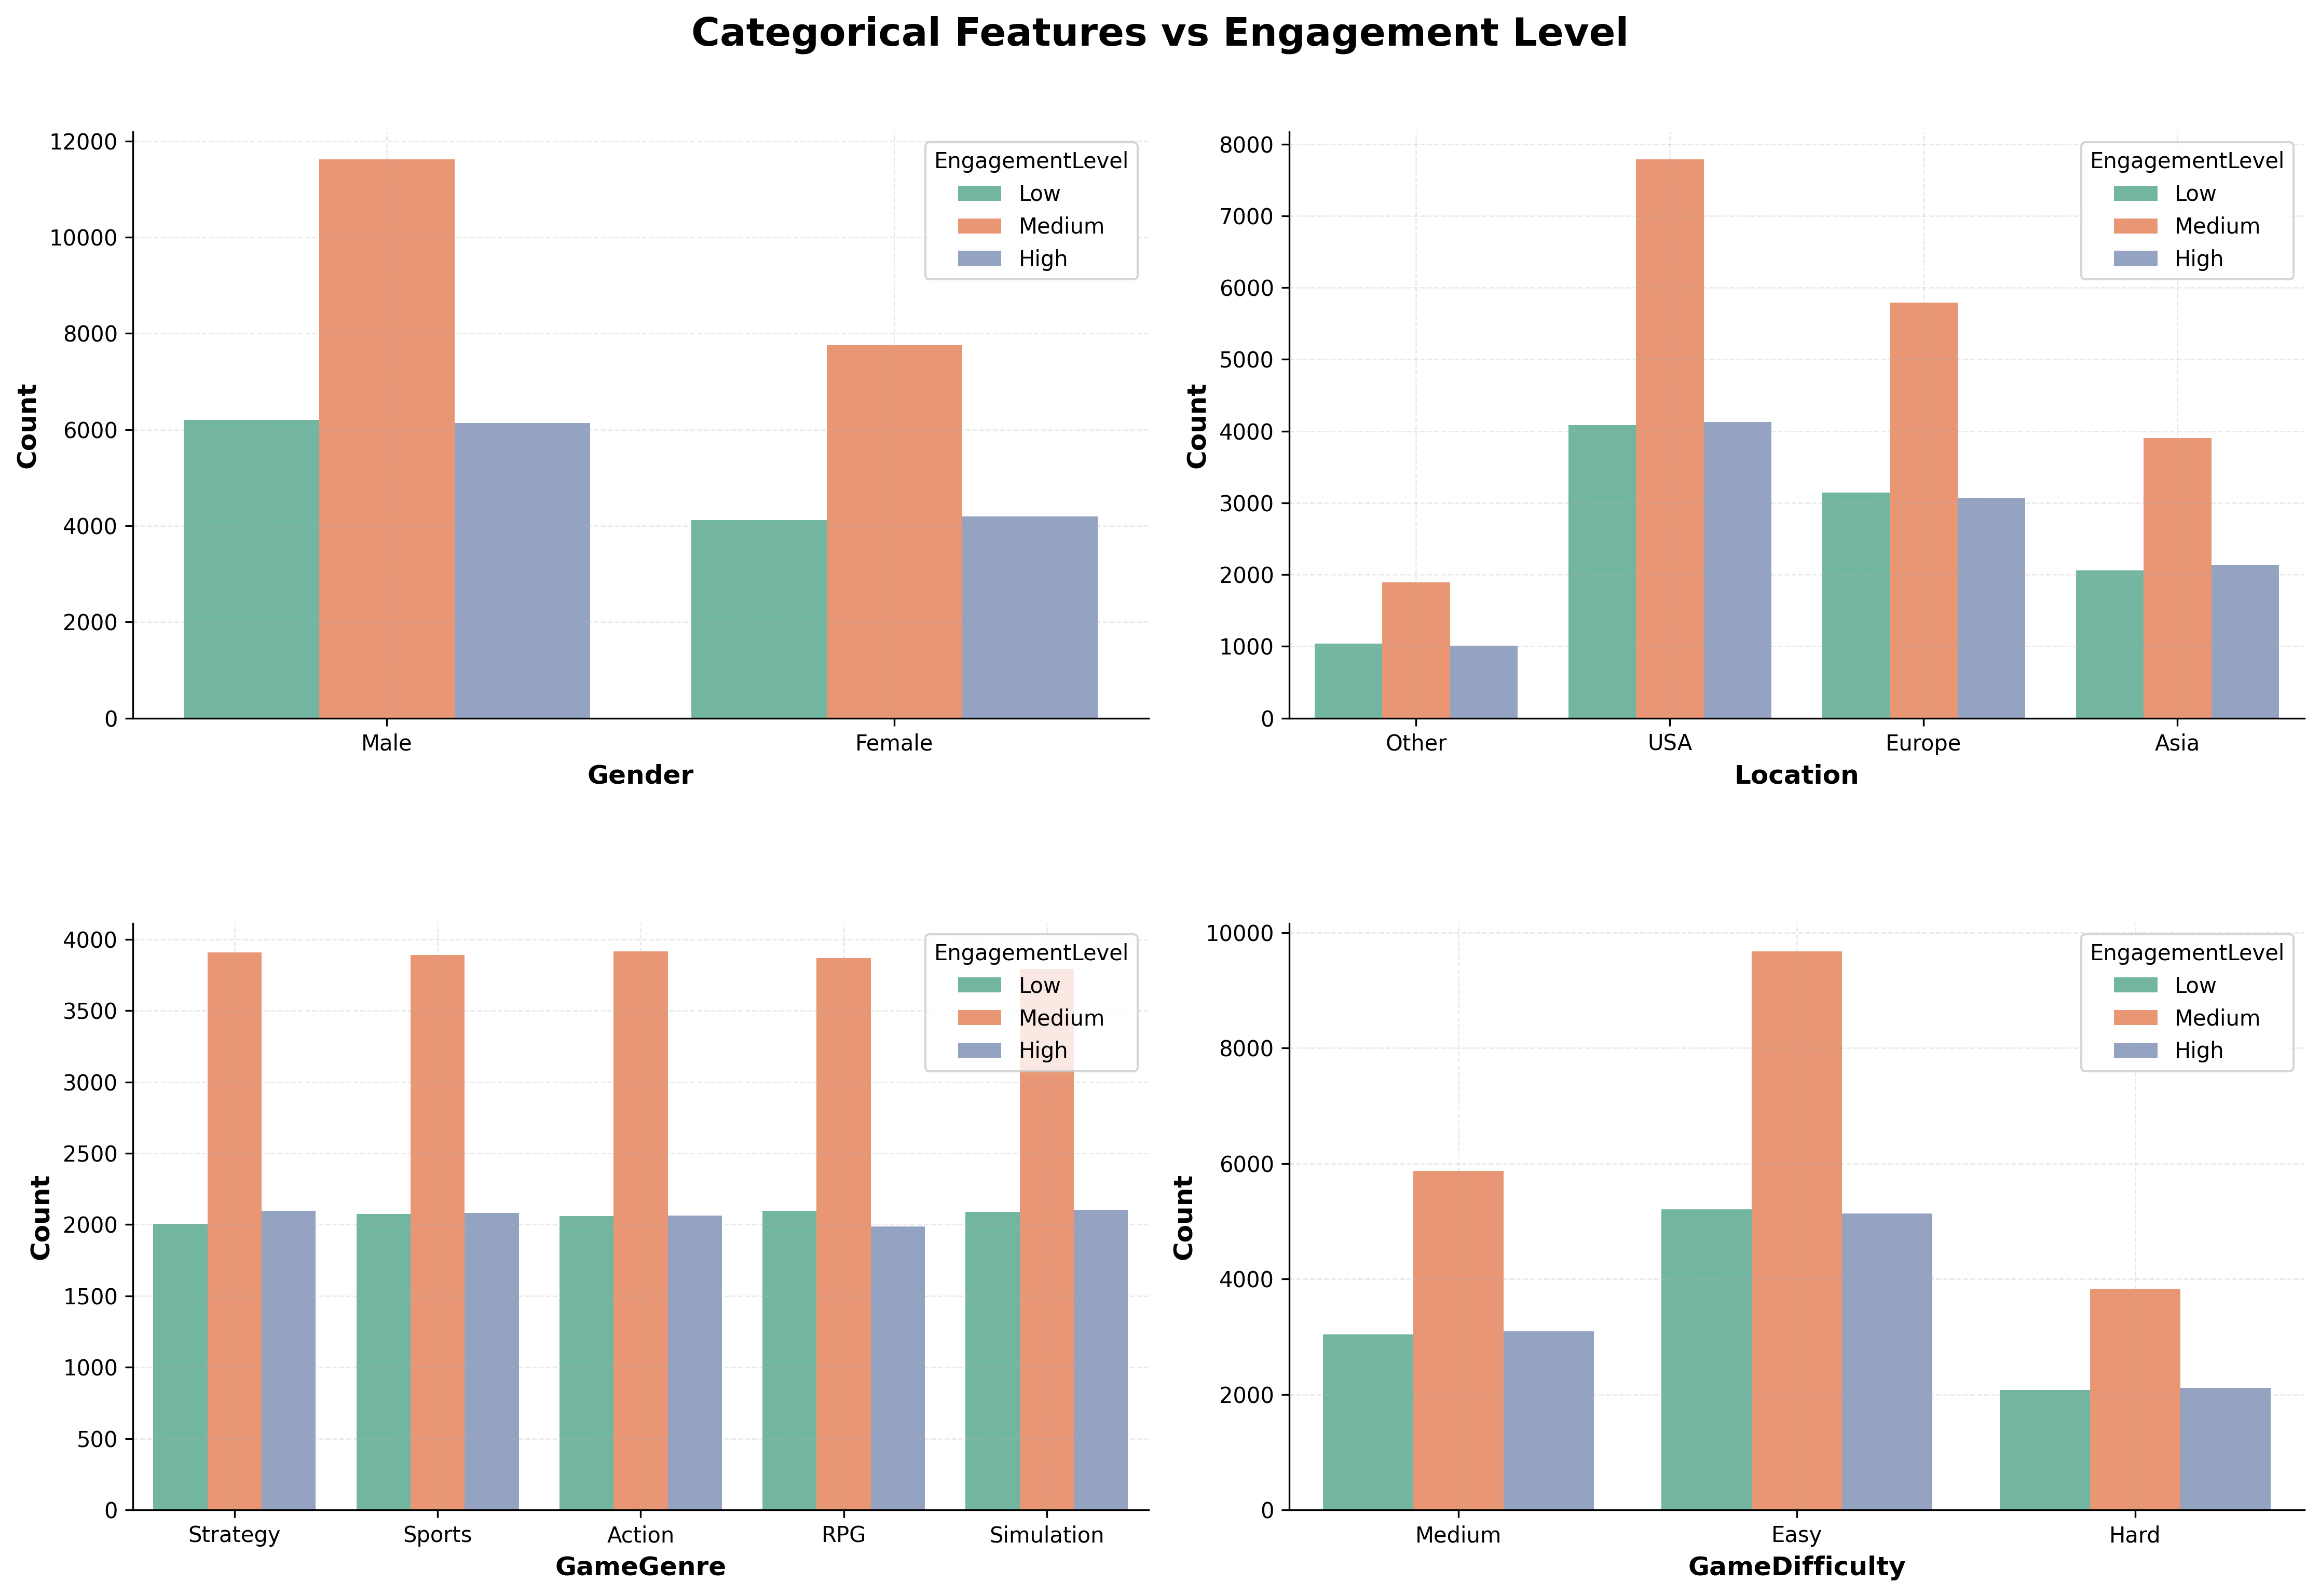

In [18]:
# CATEGORICAL FEATURES VS TARGET VARIABLE (BIVARIATE)

# categorical features (cat_cols) defined earlier -> excluding target.
# cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

n_rows = math.ceil(len(cat_cols) / 2)

fig, axes = plt.subplots(nrows= n_rows, ncols= 2, figsize= (15, 5 * n_rows))
fig.suptitle('Categorical Features vs Engagement Level', fontsize=18, weight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x= col, data= data, hue='EngagementLevel', # split each category by Engagement Level
                  palette='Set2', ax=axes[i], hue_order=['Low', 'Medium', 'High'])
    
    axes[i].set_xlabel(col, weight= 'semibold')
    axes[i].set_ylabel('Count', weight='semibold')
    axes[i].grid(linestyle='--', linewidth= 0.6, alpha= 0.3)

sns.despine()
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)

# save image 
plt.savefig('../reports/figures/eda/categorical_vs_engagement.png',
            dpi=300,
            bbox_inches='tight')

plt.show()    

**Bivariate Analysis: Categorical Features vs Engagement Level**

* **Medium engagement is the largest group everywhere**.
* This pattern is consistent across all categorical variables.

**Gender**
* Males have higher counts than females. But **Engagement proportions are the same** for both genders.
* Gender affects **volume**, not engagement behavior.

**Location**
* **USA > Europe > Asia > Other** in user count.
* Engagement distribution (Low/Medium/High) is similar across locations.
* Location affects **user base size**, not engagement level.

**Game Genre**
* All genres show **nearly identical counts** for each engagement level.
* No genre produces noticeably more High engagement users than others.
* This indicates that game genre has **minimal impact** on user engagement.

**Game Difficulty**
* Across all difficulty levels, users mostly show **Medium engagement**,
* Easy mode has more users overall, but difficulty **does not change** the engagement pattern.

**Final Conclusion**
* The categorical features display **nearly identical engagement distributions** across categories.
* This indicates that they are **weak predictors** of engagement level.
* Engagement variation is more likely explained by **numerical, behavior-based features** rather than categorical attributes.


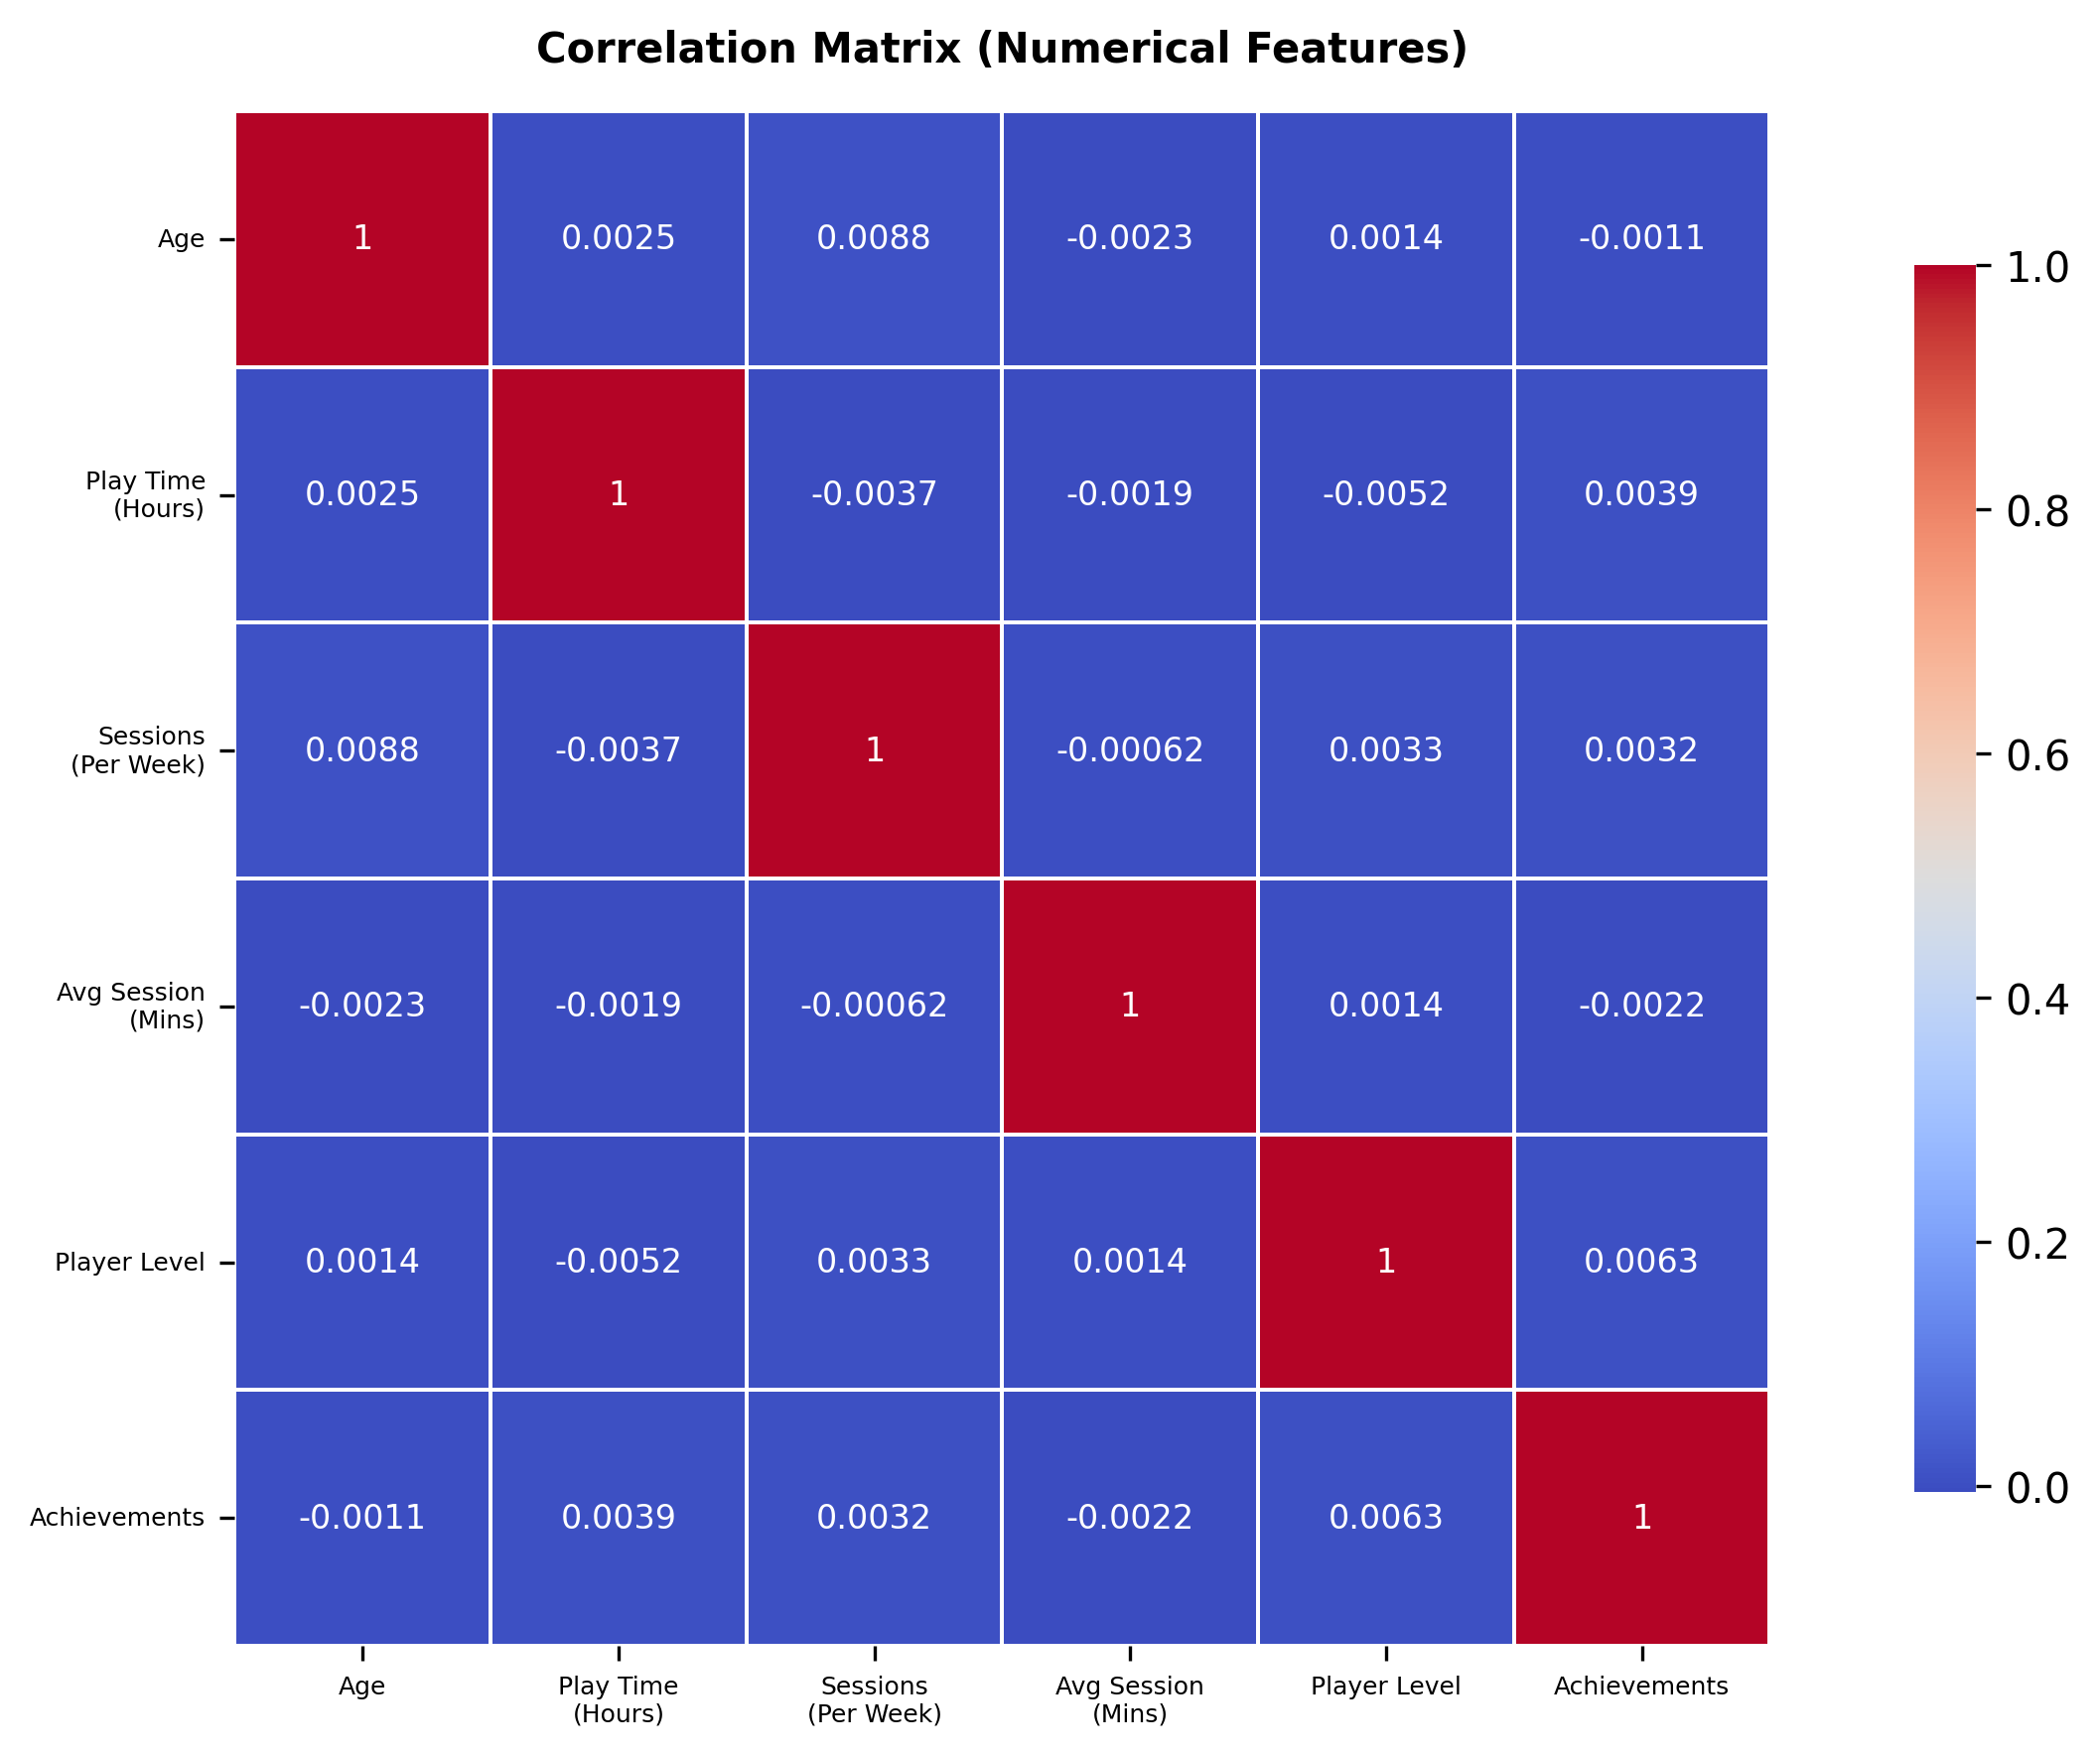

In [19]:
# CORRELATION HEATMAP (NUMERICAL FEATURES)

plt.figure(figsize=(10, 6))

corr = data[num_cols].corr()

# short label mapping
short_labels = {
    'Age': 'Age',
    'PlayTimeHours': 'Play Time\n(Hours)',
    'SessionsPerWeek': 'Sessions\n(Per Week)',
    'AvgSessionDurationMinutes': 'Avg Session\n(Mins)',
    'PlayerLevel': 'Player Level',
    'AchievementsUnlocked': 'Achievements'
}

ax = sns.heatmap(corr, annot=True, cmap='coolwarm', 
                 linewidths=0.5, linecolor='white', square=True,     
                 cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})

# apply short labels
ax.set_xticklabels([short_labels[c] for c in corr.columns], rotation=0, fontsize=6)
ax.set_yticklabels([short_labels[c] for c in corr.columns], rotation=0, fontsize=6)

plt.title("Correlation Matrix (Numerical Features)", weight="bold", pad=12, fontsize=10)
plt.tight_layout()

# save image 
plt.savefig('../reports/figures/eda/correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**Correlation Analysis of Numerical Features**

A correlation matrix was used to examine the linear relationships among the numerical features in the dataset, including **Age**, **Play Time (Hours)**, **Sessions per Week**, **Average Session Duration (Minutes)**, **Player Level**, and **Achievements Unlocked**.

**Key Observations**

* All off-diagonal correlation coefficients are **very close to zero**, typically ranging between **−0.005 and +0.009**.

* This indicates the **absence of meaningful linear relationships** between any pair of numerical features.

* No strong positive or negative correlations are observed across the dataset.

**Conclusion**

* The correlation results indicate that player behavior and progression features are **largely independent** and do not show strong linear relationships. 

* This means that linear correlation is not sufficient for understanding feature relationships, and **non-linear or target-based methods** are more suitable for further analysis.



### **Data Preprocessing**

After completing EDA, the dataset is prepared for model training through structured preprocessing steps.


#### **1. Data Preprocessing Strategy and Decisions**

##### **1.1 Missing Values and Duplicate Records**

* The dataset was examined for missing values and duplicate records. 

* **No missing values or duplicate entries were found**; therefore, no corrective preprocessing steps were required.


##### **1.2 Outlier Handling**

* Outlier treatment **was not applied.**

* Exploratory analysis indicated that numerical features **fall within realistic gameplay ranges**, and extreme values reflect valid player behavior rather than data errors. As a result, no observations were removed or capped.


##### **1.3 Class Imbalance Handling**

* The target variable exhibits **moderate imbalance** (Medium ≈ 48%, Low and High ≈ 26% each), but no class is rare. Instead of applying resampling techniques such as SMOTE, imbalance is addressed through:

- **Stratified train–test splitting** to preserve class proportions  
- **Macro-averaged F1-score** for fair multi-class evaluation  
- **Class-weighted models** where appropriate  

This approach maintains data integrity while ensuring balanced performance assessment.


##### **1.4 Encoding and Feature Scaling**

* Categorical input features are transformed using **One-Hot Encoding**, while numerical features are scaled using **Min–Max Scaling**.

* The target variable is encoded using a predefined ordinal mapping (Low = 0, Medium = 1, High = 2) for compatibility with multi-class classification models. 

* All preprocessing steps are implemented within **a unified pipeline to prevent data leakage** and ensure consistent transformation across training and test sets.


##### **1.5 Summary**

* No additional data cleaning or resampling techniques were required. 
* Preprocessing focuses on stratified splitting, appropriate encoding, and feature scaling within a pipeline-based workflow to maintain reproducibility and modeling integrity.


#### **2. Define Features and Target**

In [3]:
# Define X and y
X = data.drop(['EngagementLevel', 'PlayerID'], axis=1) # removing the target variable and unique identifier
y = data['EngagementLevel']

In [4]:
# manual ordinal encoding for engagement levels (Low < Medium < High)
label_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

# convert target labels to numeric values using predefined mapping
y_encoded = y.map(label_mapping)

# class names in logical order for reporting and visualization
class_names = ['Low', 'Medium', 'High']

#### **3. Train-Test Split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size= 0.25, 
    random_state= 42, 
    stratify= y_encoded # stratified to maintain class balance
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 30025
Testing samples  : 10009


#### **4. Build the Preprocessing Pipeline**

In [23]:
# Identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns 

In [24]:
# Build the preprocessing pipeline -> Preprocessing is applied inside the pipeline to prevent data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) # safely handling unseen values, ignoring them
    ] 
)

### **Baseline Model Training and Evaluation**

#### **1. Define Baseline Classification Models**

In [25]:
# Define baseline classification models (default-style configurations)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42)
}

# Only essential technical parameters were set to ensure proper training and reproducibility.
# No optimization or class imbalance handling was applied.
# These models represent true baseline performance.

#### **2. Baseline Model Training and Evaluation**

In [26]:
baseline_results = []

for name, model in baseline_models.items():
    # create the full pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # perform 5-fold cross-validation on TRAINING data
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv= 5,
        scoring= 'f1_macro'
    )

    # calculate the average CV score 
    macro_f1 = cv_scores.mean()

    baseline_results.append({
        'Model': name,
        'CV Macro F1-Score': macro_f1})

All baseline models were trained using a common preprocessing pipeline and evaluated using 5-fold cross-validation on the training data with the **macro-averaged F1-score**.

This ensures a **fair comparison** between models while preserving the test set for final evaluation. The macro F1-score accounts for class imbalance by weighting all engagement levels equally.

In [27]:
# Create and display the leaderboard
baseline_results_df = pd.DataFrame(baseline_results).sort_values(
                      'CV Macro F1-Score', ascending=False).reset_index(drop=True)

# add human-readable ranking
baseline_results_df.index = baseline_results_df.index + 1
baseline_results_df.index.name = 'Rank'
baseline_results_df

,Model,CV Macro F1-Score
Rank,,
1,XGBoost,0.907854
2,Gradient Boosting,0.900944
3,Random Forest,0.890495
4,SVM,0.865704
5,Naive Bayes,0.821046
6,Decision Tree,0.818525
7,Logistic Regression,0.815617
8,AdaBoost,0.791428
9,KNN,0.659017


#### **3. Visualize the Baseline Model Comparison**

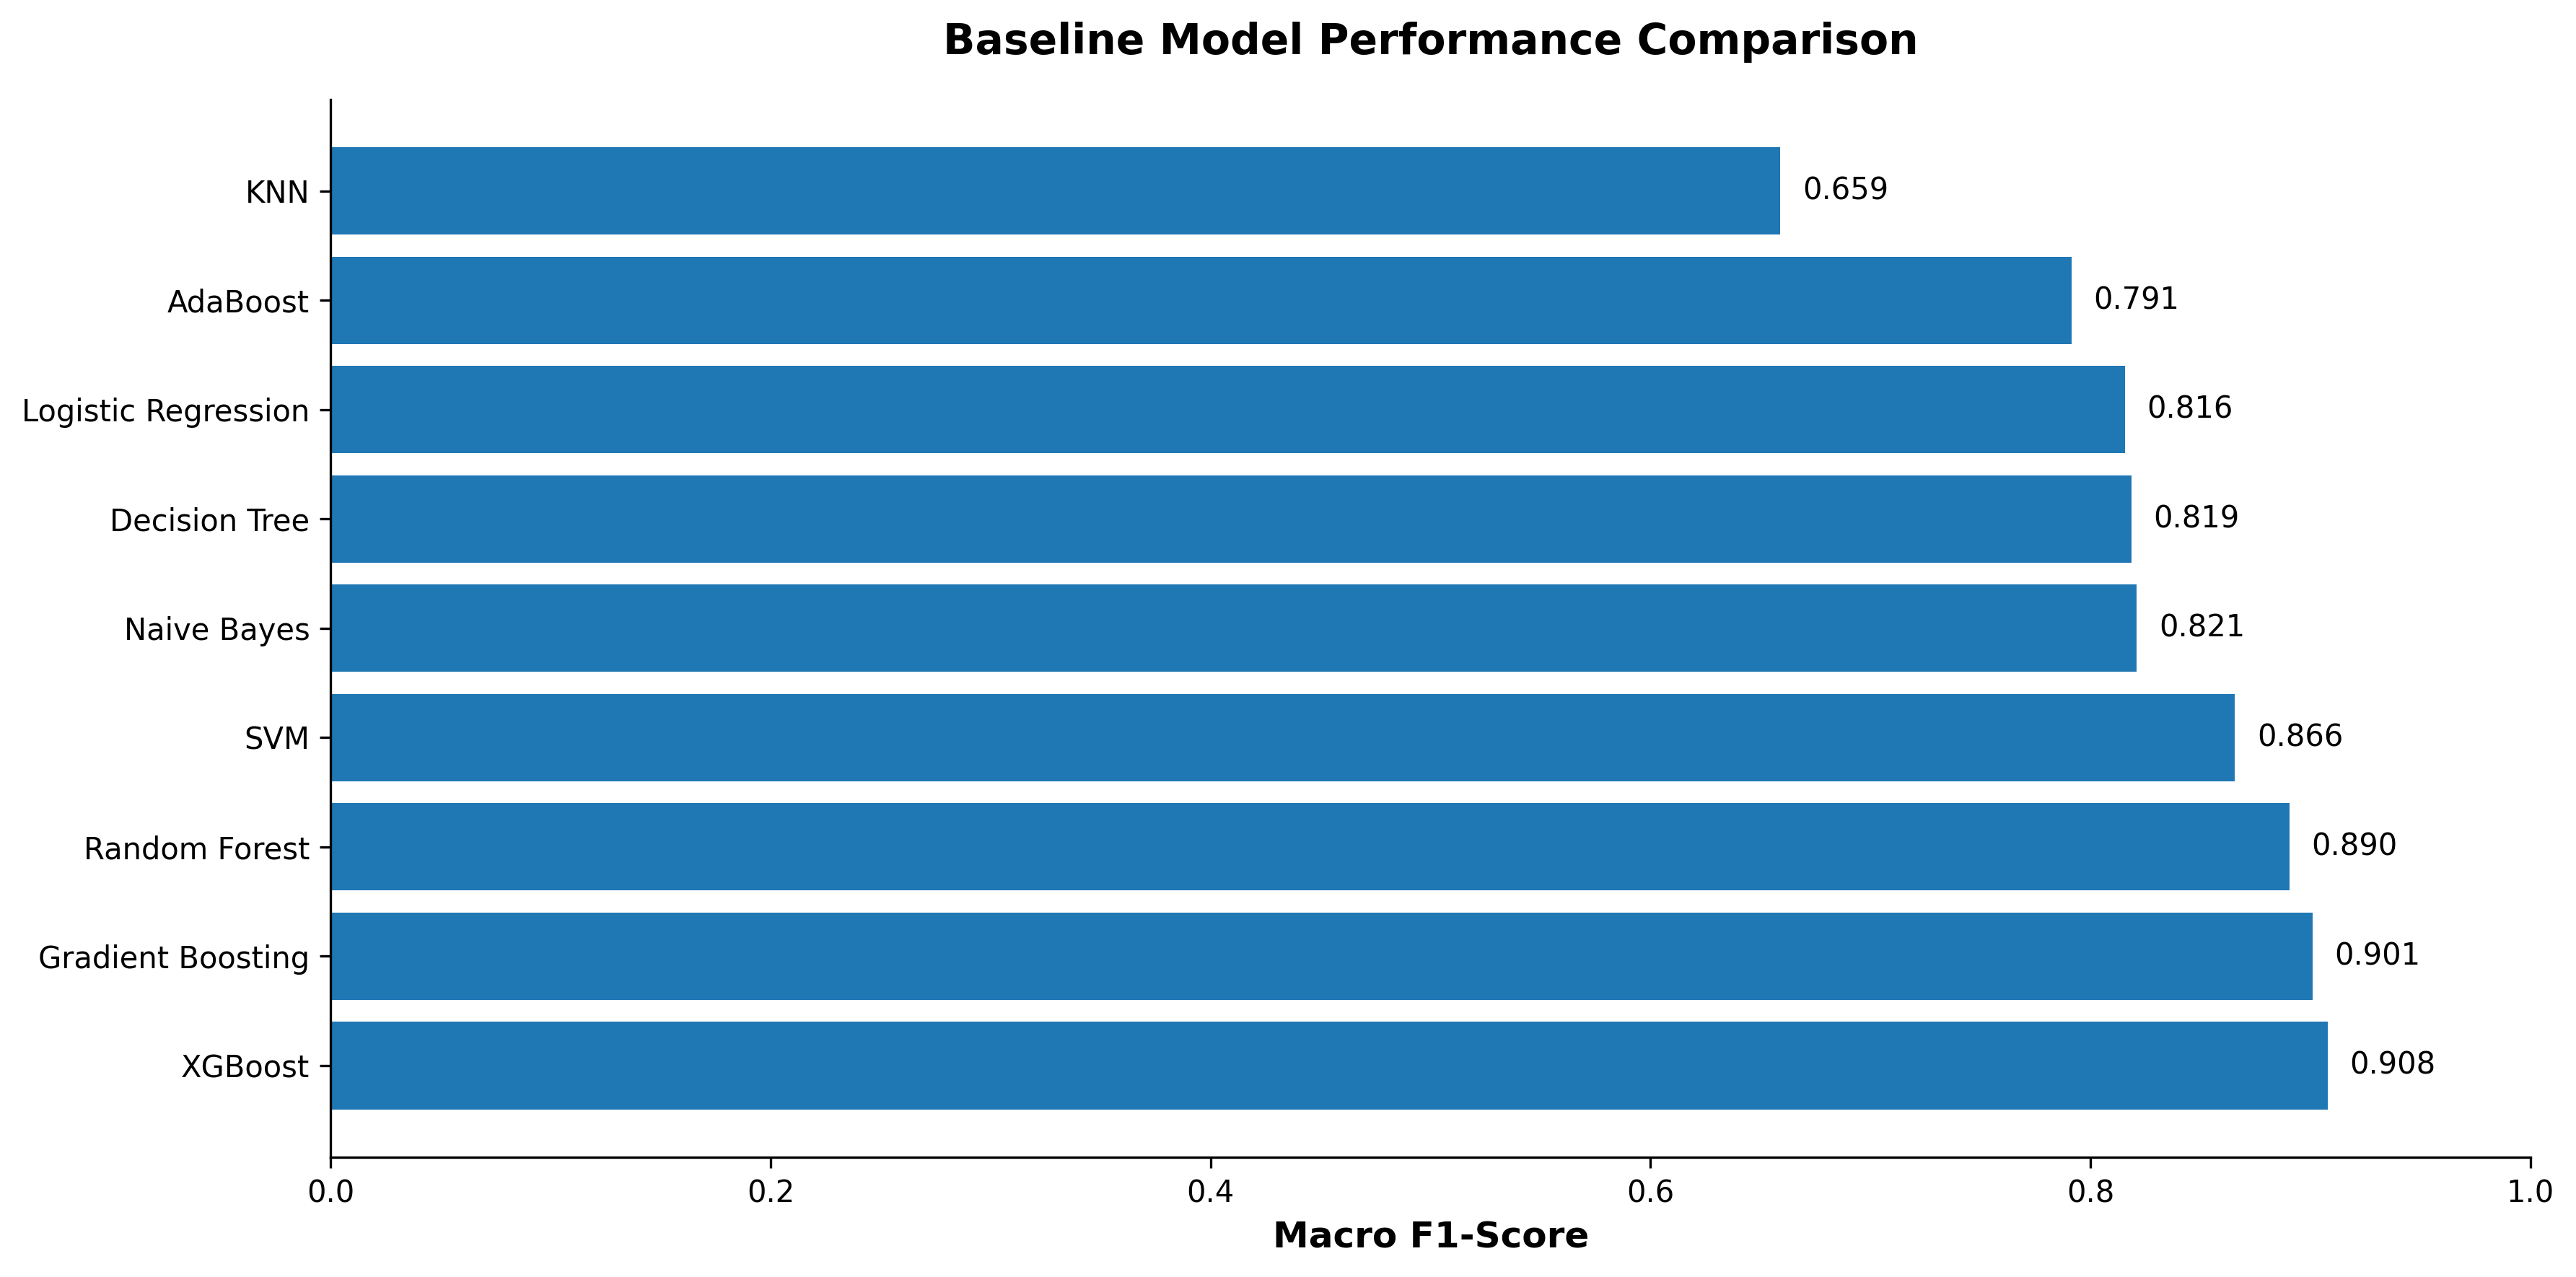

In [28]:
# visualize the baseline model comparison

plt.figure(figsize=(12, 6))
bars = plt.barh(baseline_results_df['Model'], baseline_results_df['CV Macro F1-Score'])
plt.title('Baseline Model Performance Comparison')
plt.xlabel('Macro F1-Score', weight='semibold')
plt.xlim([0, 1])

# add value labels on bars 
for bar in bars:
    width = bar.get_width()
    plt.text(x= width + 0.01,
             y= bar.get_y() + bar.get_height() / 2,
             s= f'{width:.3f}', ha='left', va='center')

plt.tight_layout()

# save image  
plt.savefig('../reports/figures/modeling/baseline_model_comparison.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

#### **4. Final Baseline Model Selection and Evaluation**

In [29]:
# FINAL BASELINE MODEL SELECTION

# Best baseline model (highest Macro F1-score)
best_model_name = baseline_results_df.iloc[0]['Model']

# Retrieve the corresponding model definition
best_model = baseline_models[best_model_name]

In [30]:
# FINAL BASELINE PIPELINE

# Rebuild the preprocessing + model pipeline for the best baseline model
# This ensures a clean, reproducible reference baseline for detailed evaluation
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# fit the final baseline pipeline on the training data
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
# FINAL BASELINE EVALUATION

# Generate predictions on the test set
y_pred = final_pipeline.predict(X_test)

# Print the Classification Report
print(f"{best_model_name} Baseline Classification Report\n".upper())
print(classification_report(y_test, y_pred, target_names= class_names))

XGBOOST BASELINE CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Low       0.92      0.89      0.90      2581
      Medium       0.91      0.95      0.93      4844
        High       0.93      0.88      0.90      2584

    accuracy                           0.92     10009
   macro avg       0.92      0.91      0.91     10009
weighted avg       0.92      0.92      0.92     10009



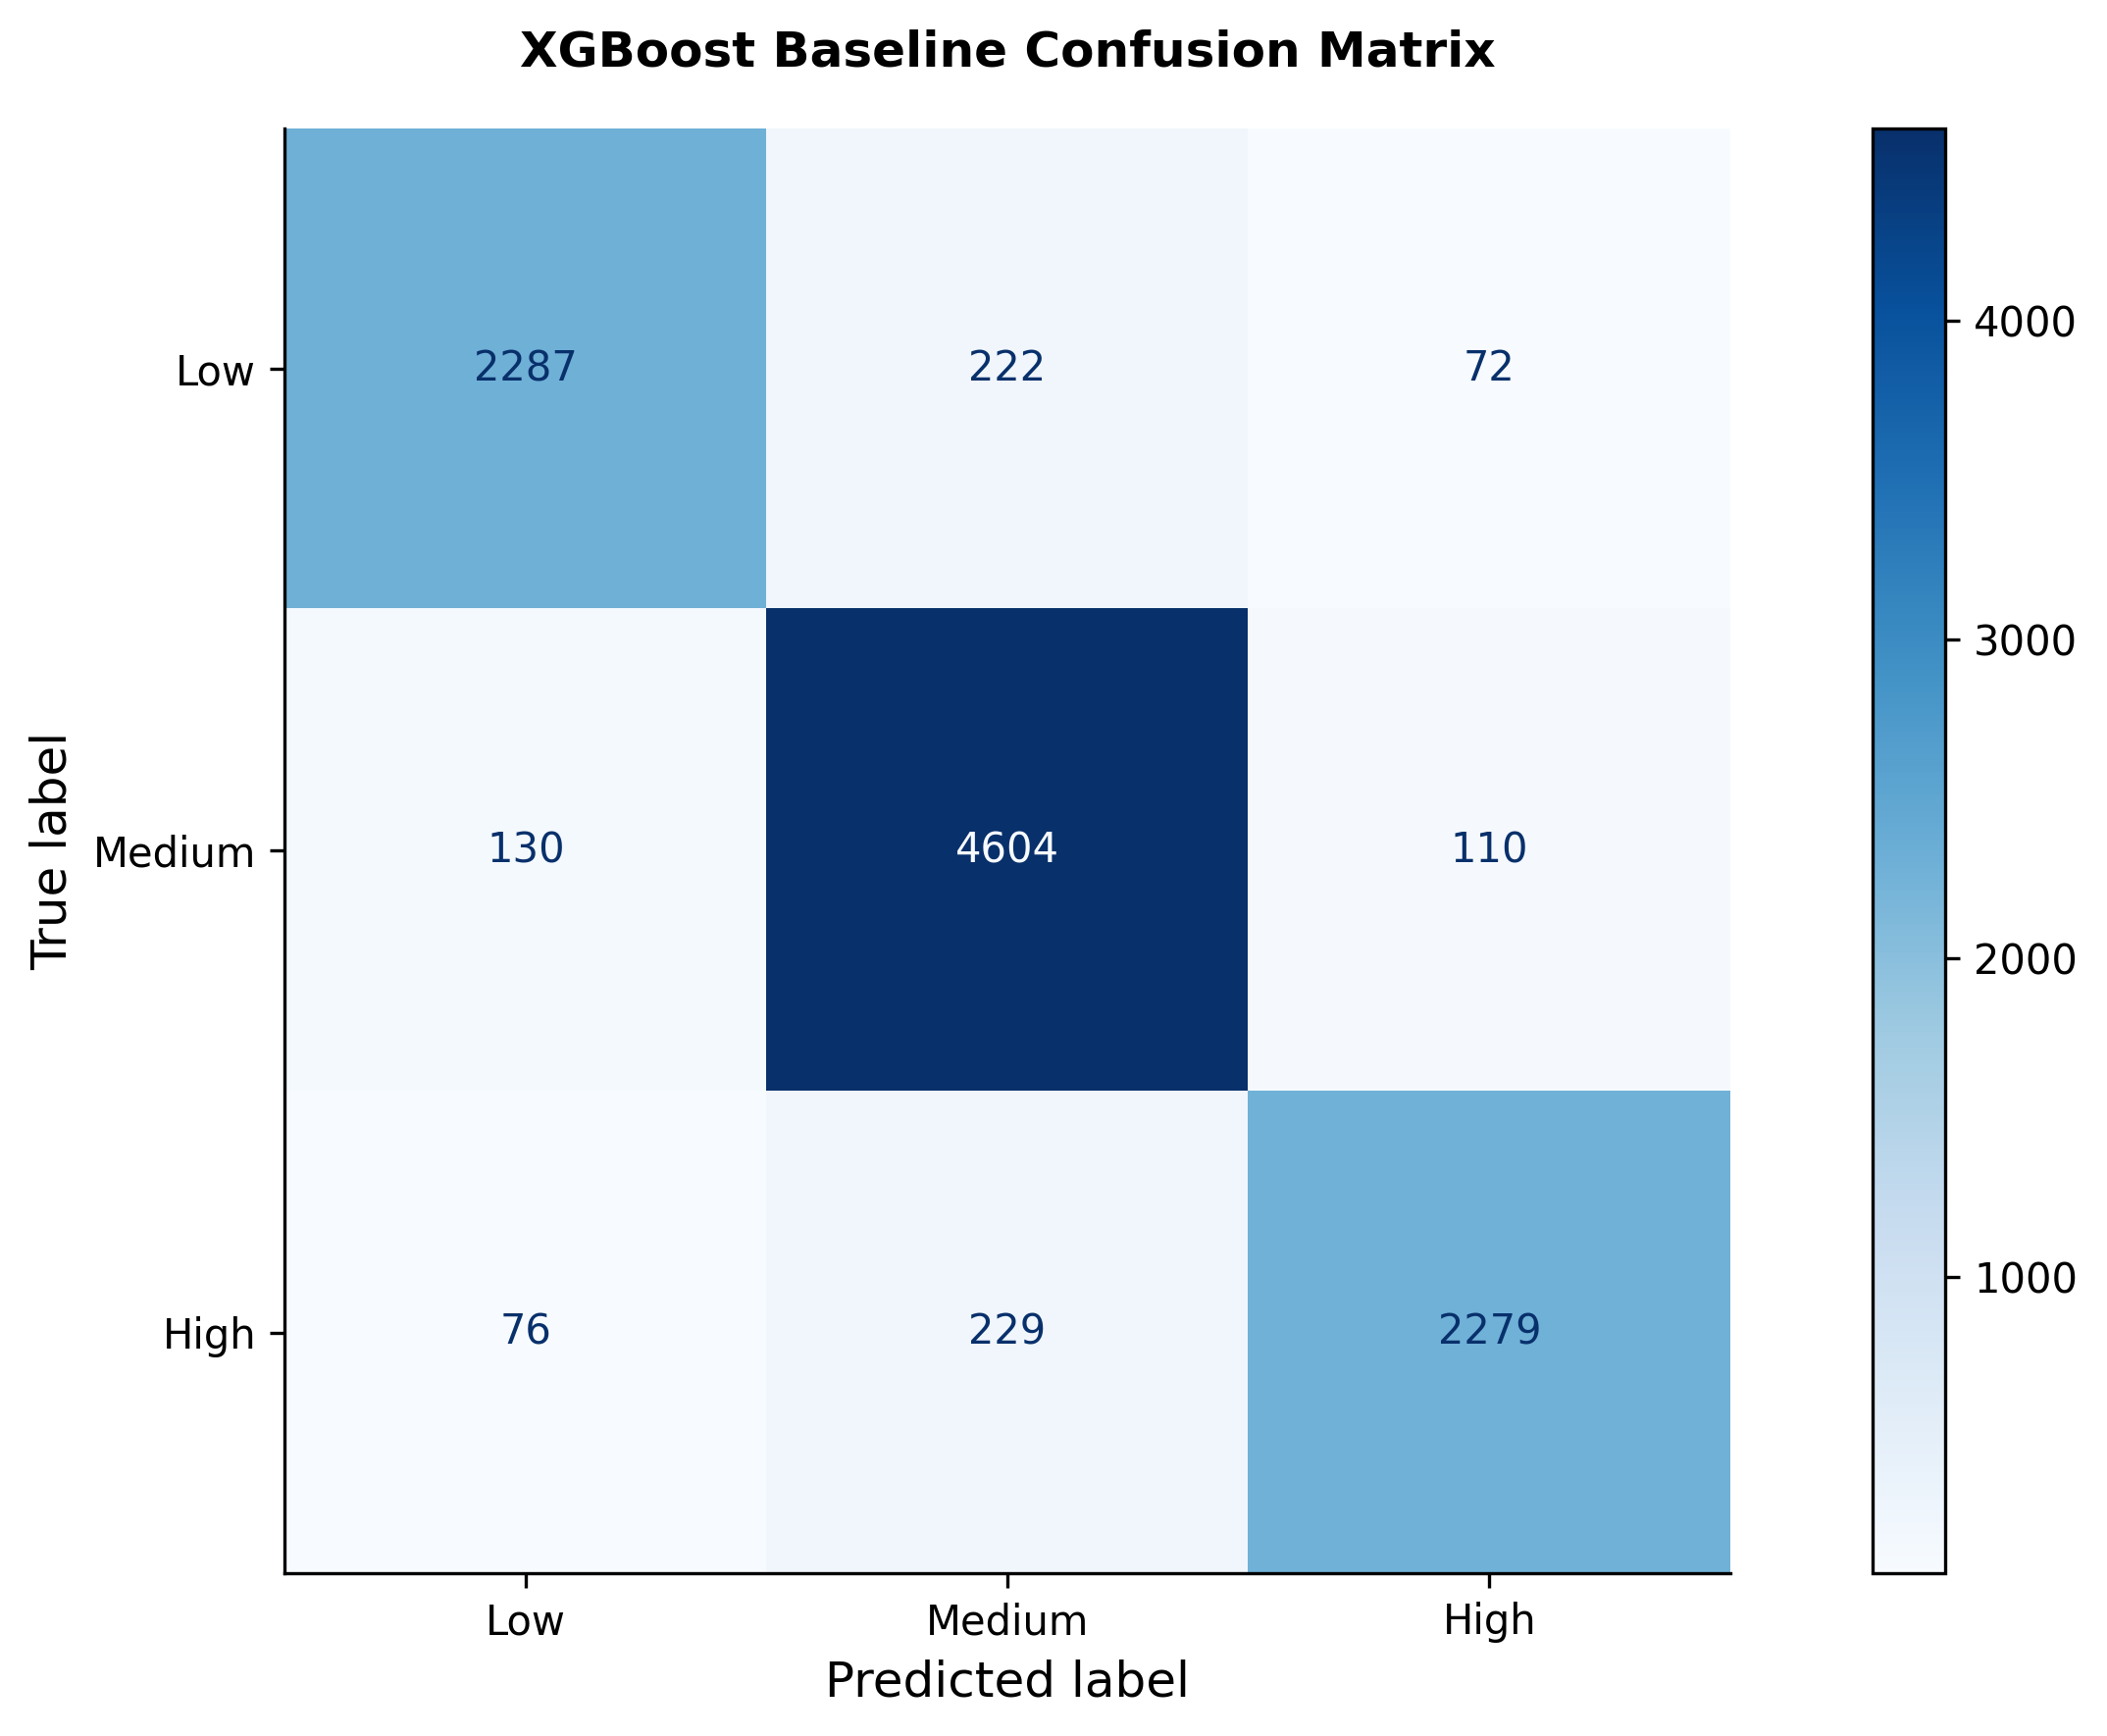

In [32]:
# Plot the confusion matrix to analyze baseline error patterns

fig, ax = plt.subplots(figsize=(10, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels= class_names,  # names shown on axes
    ax=ax,
    cmap='Blues'
)

ax.set_title(f'{best_model_name} Baseline Confusion Matrix', size=12)
plt.tight_layout()

# save image  
plt.savefig('../reports/figures/modeling/baseline_confusion_matrix.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

**Baseline Phase Analysis**

* Models were compared using **5-fold cross-validation** with the **macro F1-score**. 

* **XGBoost** achieved the highest performance, indicating stronger class balance and better capture of non-linear engagement patterns.

### **Hyperparameter Optimization & Model Tuning**

The **top three baseline models** were further optimized using **RandomizedSearchCV** to improve generalization performance while controlling computational cost.


#### **1. Select the Top Three Models**

In [33]:
# select the top 3 models from baseline results 
top_models = baseline_results_df.iloc[:3]['Model'].tolist()
top_models

['XGBoost', 'Gradient Boosting', 'Random Forest']

#### **2. Define Hyperparameter Grids**


In [34]:
# Define hyperparameter grids for the top 3 models

param_grids = {
    "XGBoost": {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [4, 6, 8],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0]
    },
    "Random Forest": {
        'model__n_estimators': [200, 300],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 'log2']
    },
    "Gradient Boosting": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 5],
        'model__subsample': [0.8, 1.0]
    }
}

#### **3. Hyperparameter Tuning (Randomized Search)**


In [35]:
# Containers to store tuning outcomes
tuned_results = []        # summary table (for comparison & reporting)
best_estimators = {}      # best trained pipeline per model

# Hyperparameter Optimization Loop
for name in top_models:
    print(f"Tuning {name}....")

    # Clone the model to ensure each model is tuned independently
    model_instance = clone(baseline_models[name])

    # Apply class weighting only for Random Forest
    if name == 'Random Forest':
        model_instance.set_params(class_weight='balanced')

    # Build the optimization pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_instance)
    ])

    # Randomized Search with 5-Fold Cross-Validation
    search = RandomizedSearchCV(
    estimator= pipeline,                    # full preprocessing + model pipeline
    param_distributions= param_grids[name], # hyperparameter search space
    n_iter= 20,                             # number of random parameter combinations
    cv= 5,                                  # 5-fold stratified cross-validation
    scoring= 'f1_macro',                    # evaluation metric (treats all classes equally)
    n_jobs= -1,                             # use all available CPU cores
    random_state= 42,                       # ensure reproducible results
    verbose= 1                              # display tuning progress
    )

    # Fit hyperparameter search on training data ONLY
    search.fit(X_train, y_train)

    # Store tuning results
    tuned_results.append({
        'Model': name,
        'Best CV F1': search.best_score_,
        'Best Params': search.best_params_
    })

    # Store the best-performing trained pipeline for final evaluation
    best_estimators[name] = search.best_estimator_
 
print("\nModel optimization completed successfully!!")
print("Tuned models:", ", ".join(top_models))

Tuning XGBoost....
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tuning Gradient Boosting....
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tuning Random Forest....
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Model optimization completed successfully!!
Tuned models: XGBoost, Gradient Boosting, Random Forest


#### **4. Tuned Model Ranking**

In [36]:
# Create a ranked table of tuned model performance
tuned_result_df = pd.DataFrame(tuned_results).sort_values('Best CV F1', ascending= False).reset_index(drop= True)
tuned_result_df.index = tuned_result_df.index + 1

display(tuned_result_df)

,Model,Best CV F1,Best Params
1,XGBoost,0.912204,"{'model__subsample': 1.0, 'model__n_estimators..."
2,Gradient Boosting,0.910500,"{'model__subsample': 0.8, 'model__n_estimators..."
3,Random Forest,0.896792,"{'model__n_estimators': 300, 'model__min_sampl..."


**The tuned XGBoost model** achieved the highest cross-validated macro F1-score, confirming its robustness relative to other ensemble methods.


In [37]:
# Select best model based on CV performance
best_tuned_model_name = tuned_result_df.iloc[0]['Model']
best_tuned_model = best_estimators[best_tuned_model_name]

print("Best Model:", best_tuned_model_name)

Best Model: XGBoost


### **Final Model Evaluation on Test Data**

#### **1. Generate Predictions on Unseen Test Data**

In [38]:
# Final Evaluation on the unseen Test Set
y_test_pred = best_tuned_model.predict(X_test)

#### **2. Final Classification Report**

In [39]:
print("="*60)
print(f"FINAL PERFORMANCE  REPORT: {best_tuned_model_name}".center(60))
print("="*60)
print(classification_report(y_true= y_test, 
                            y_pred= y_test_pred, 
                            target_names= class_names, # Labels ordered as Low → Medium → High
                            ))

             FINAL PERFORMANCE  REPORT: XGBoost             
              precision    recall  f1-score   support

         Low       0.92      0.88      0.90      2581
      Medium       0.91      0.95      0.93      4844
        High       0.93      0.88      0.90      2584

    accuracy                           0.92     10009
   macro avg       0.92      0.91      0.91     10009
weighted avg       0.92      0.92      0.92     10009



#### **3. Confusion Matrix (Test Data)**

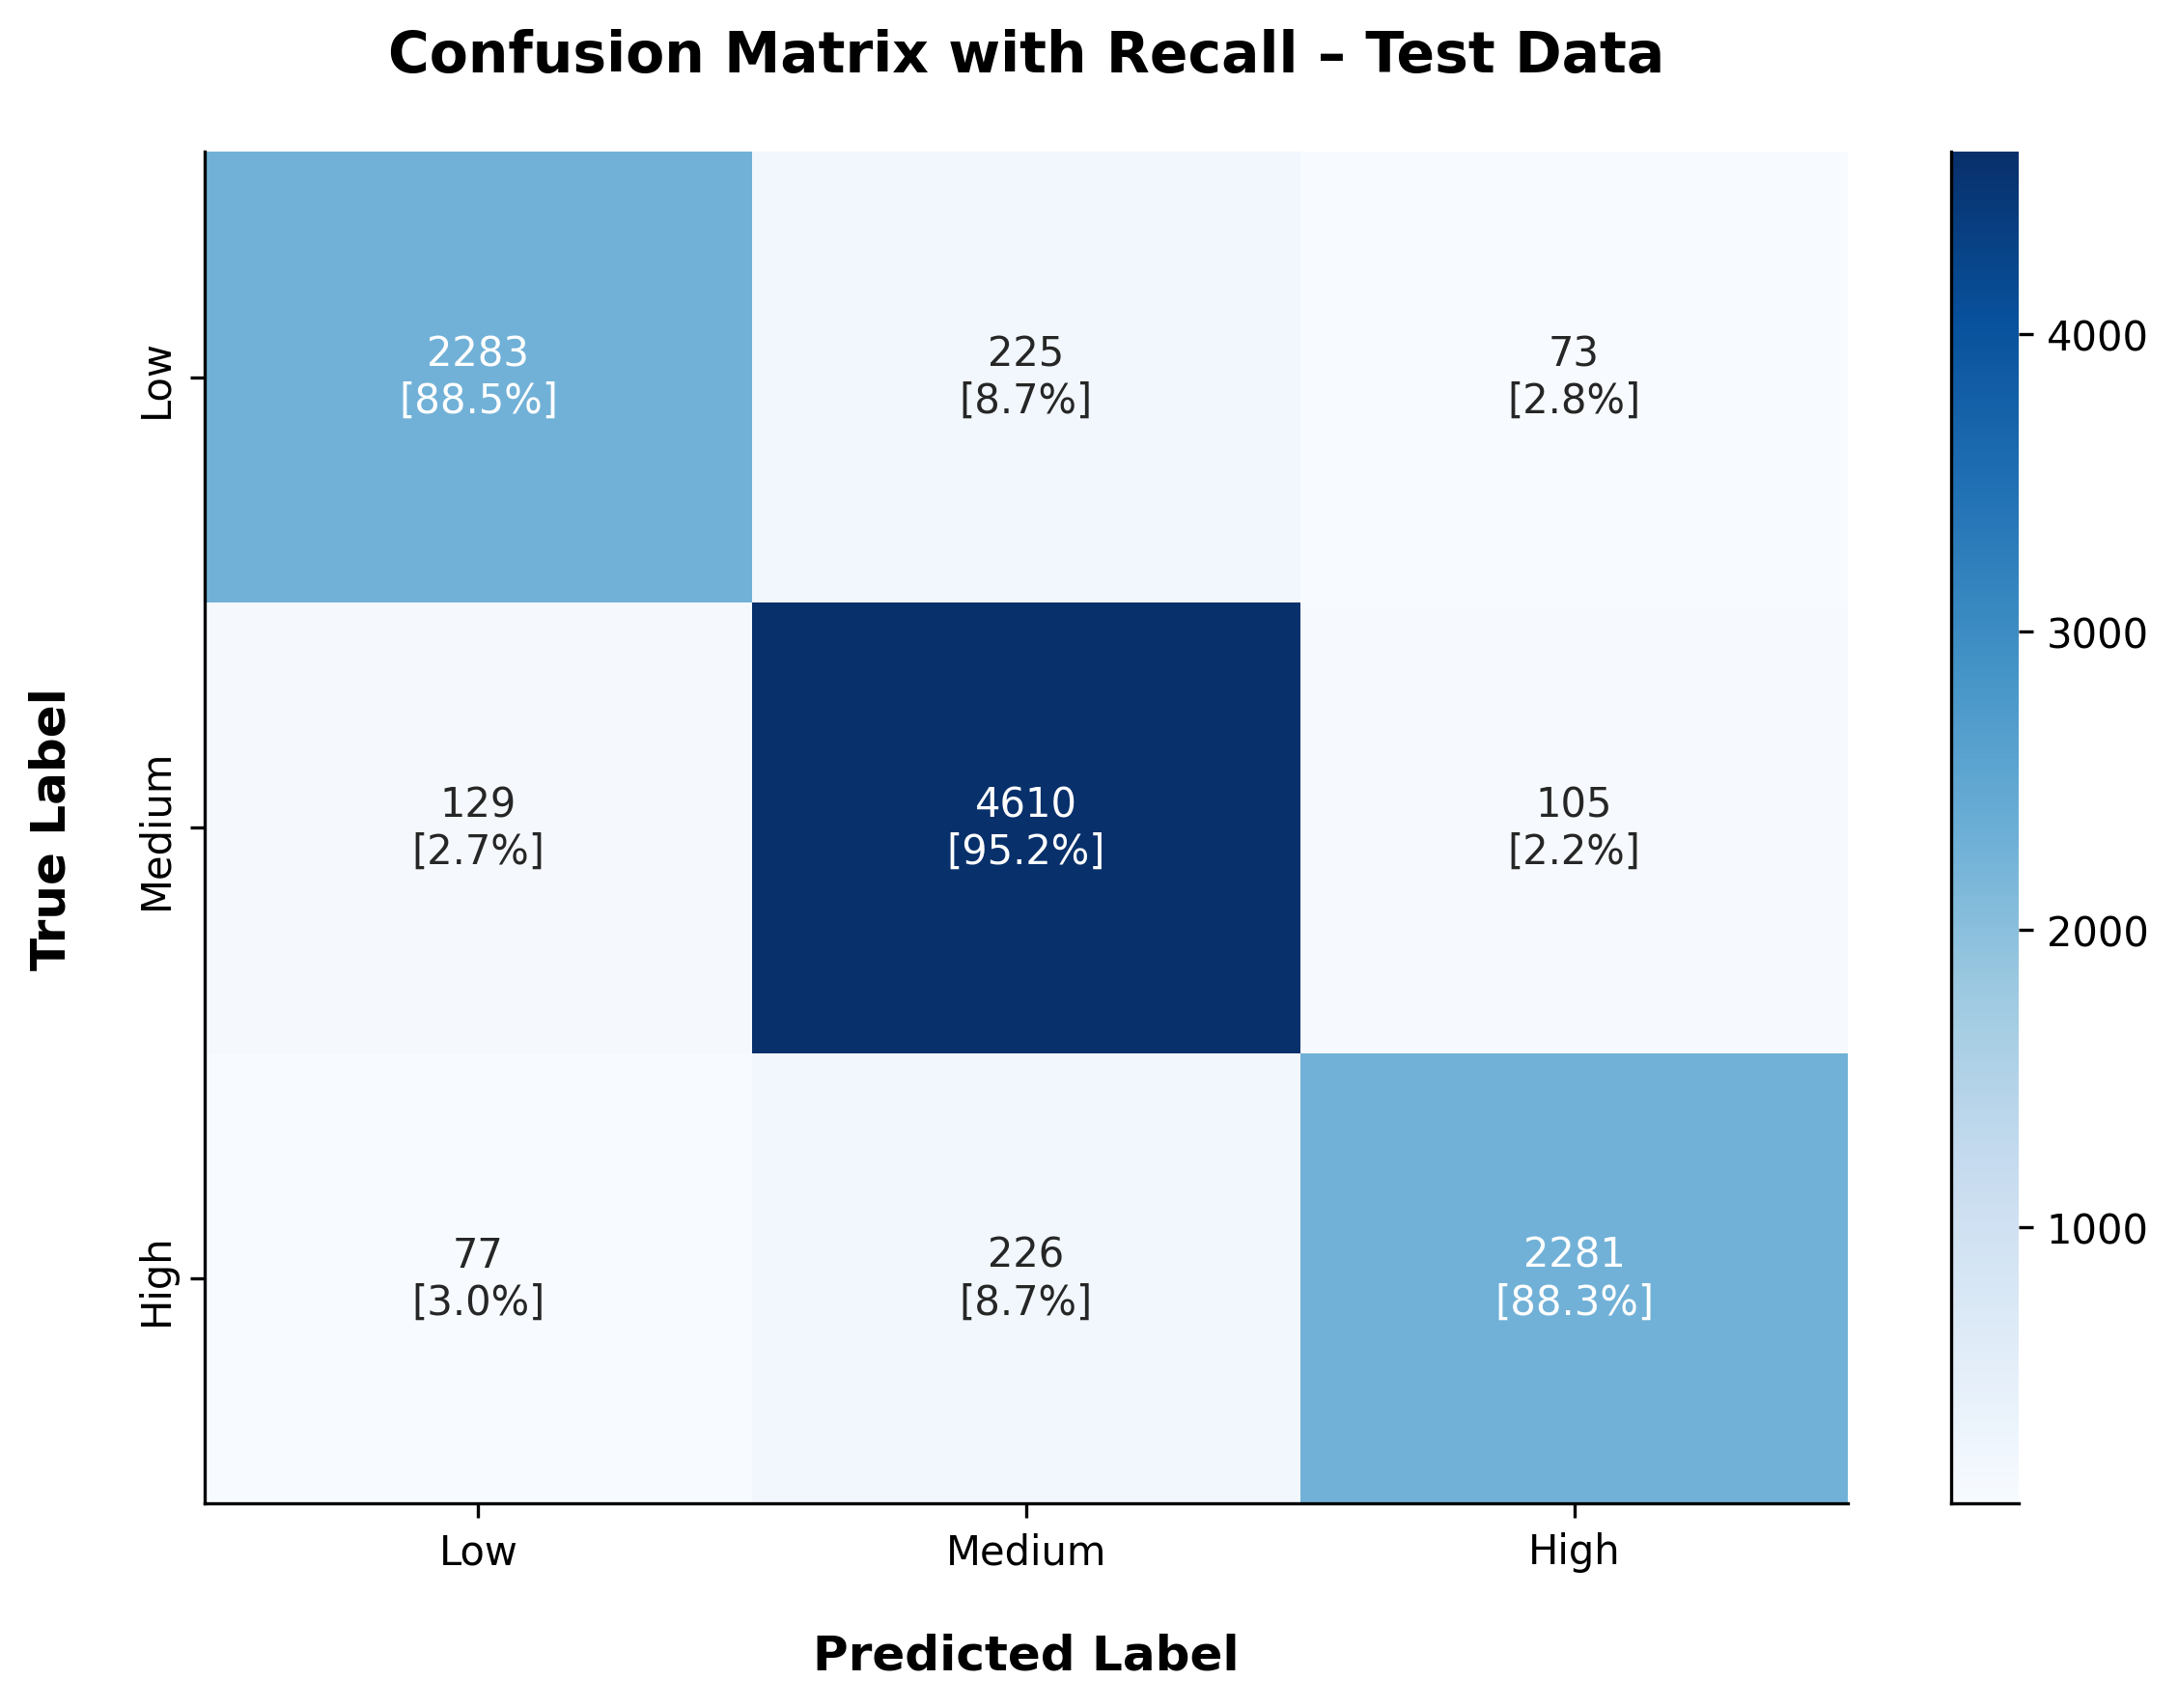

In [40]:
cm = confusion_matrix(y_test, y_test_pred)

# Build annotations: count + row-wise percentage (recall)
annot = np.array([
    [f"{cm[i,j]}\n[{cm[i,j]/cm[i].sum()*100:.1f}%]"
     for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(data= cm,
            ax= ax,
            annot= annot,
            fmt= '',
            cmap= 'Blues',
            xticklabels= class_names,
            yticklabels= class_names
            )

ax.set_title("Confusion Matrix with Recall – Test Data", pad=20)
ax.set_xlabel("Predicted Label", weight= 'semibold', labelpad=15)
ax.set_ylabel("True Label", weight= 'semibold', labelpad=15)

plt.tight_layout()
sns.despine()

# save image  
plt.savefig('../reports/figures/modeling/final_model_confusion_matrix.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

#### **4. Feature Importance (Final Model)**

In [41]:
# extract trained model and preprocessor
model = best_tuned_model.named_steps['model']
preprocessor = best_tuned_model.named_steps['preprocessor']

# check if model supports feature importance
if hasattr(model, "feature_importances_"):

    importances = model.feature_importances_

    # rebuild feature names after preprocessing
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

    features = (list(num_cols) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))

    # Create sorted feature-importance table
    feature_imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    # aggregate one-hot encoded features
    feature_imp_df['ParentFeature'] = feature_imp_df['Feature'].str.split('_').str[0]

    # aggregate and rank feature importance
    parent_feature_imp = (
        feature_imp_df
        .groupby('ParentFeature', as_index=False)['Importance']
        .sum()
        .sort_values('Importance', ascending=False)
        .reset_index(drop=True)
    )
    
    # display top 5 important features
    print(parent_feature_imp.head(5))

else:
    print(f"Feature importance is not available for {best_tuned_model_name}.")

               ParentFeature  Importance
0            SessionsPerWeek    0.371864
1  AvgSessionDurationMinutes    0.247047
2                  GameGenre    0.092876
3                   Location    0.074498
4             GameDifficulty    0.060484


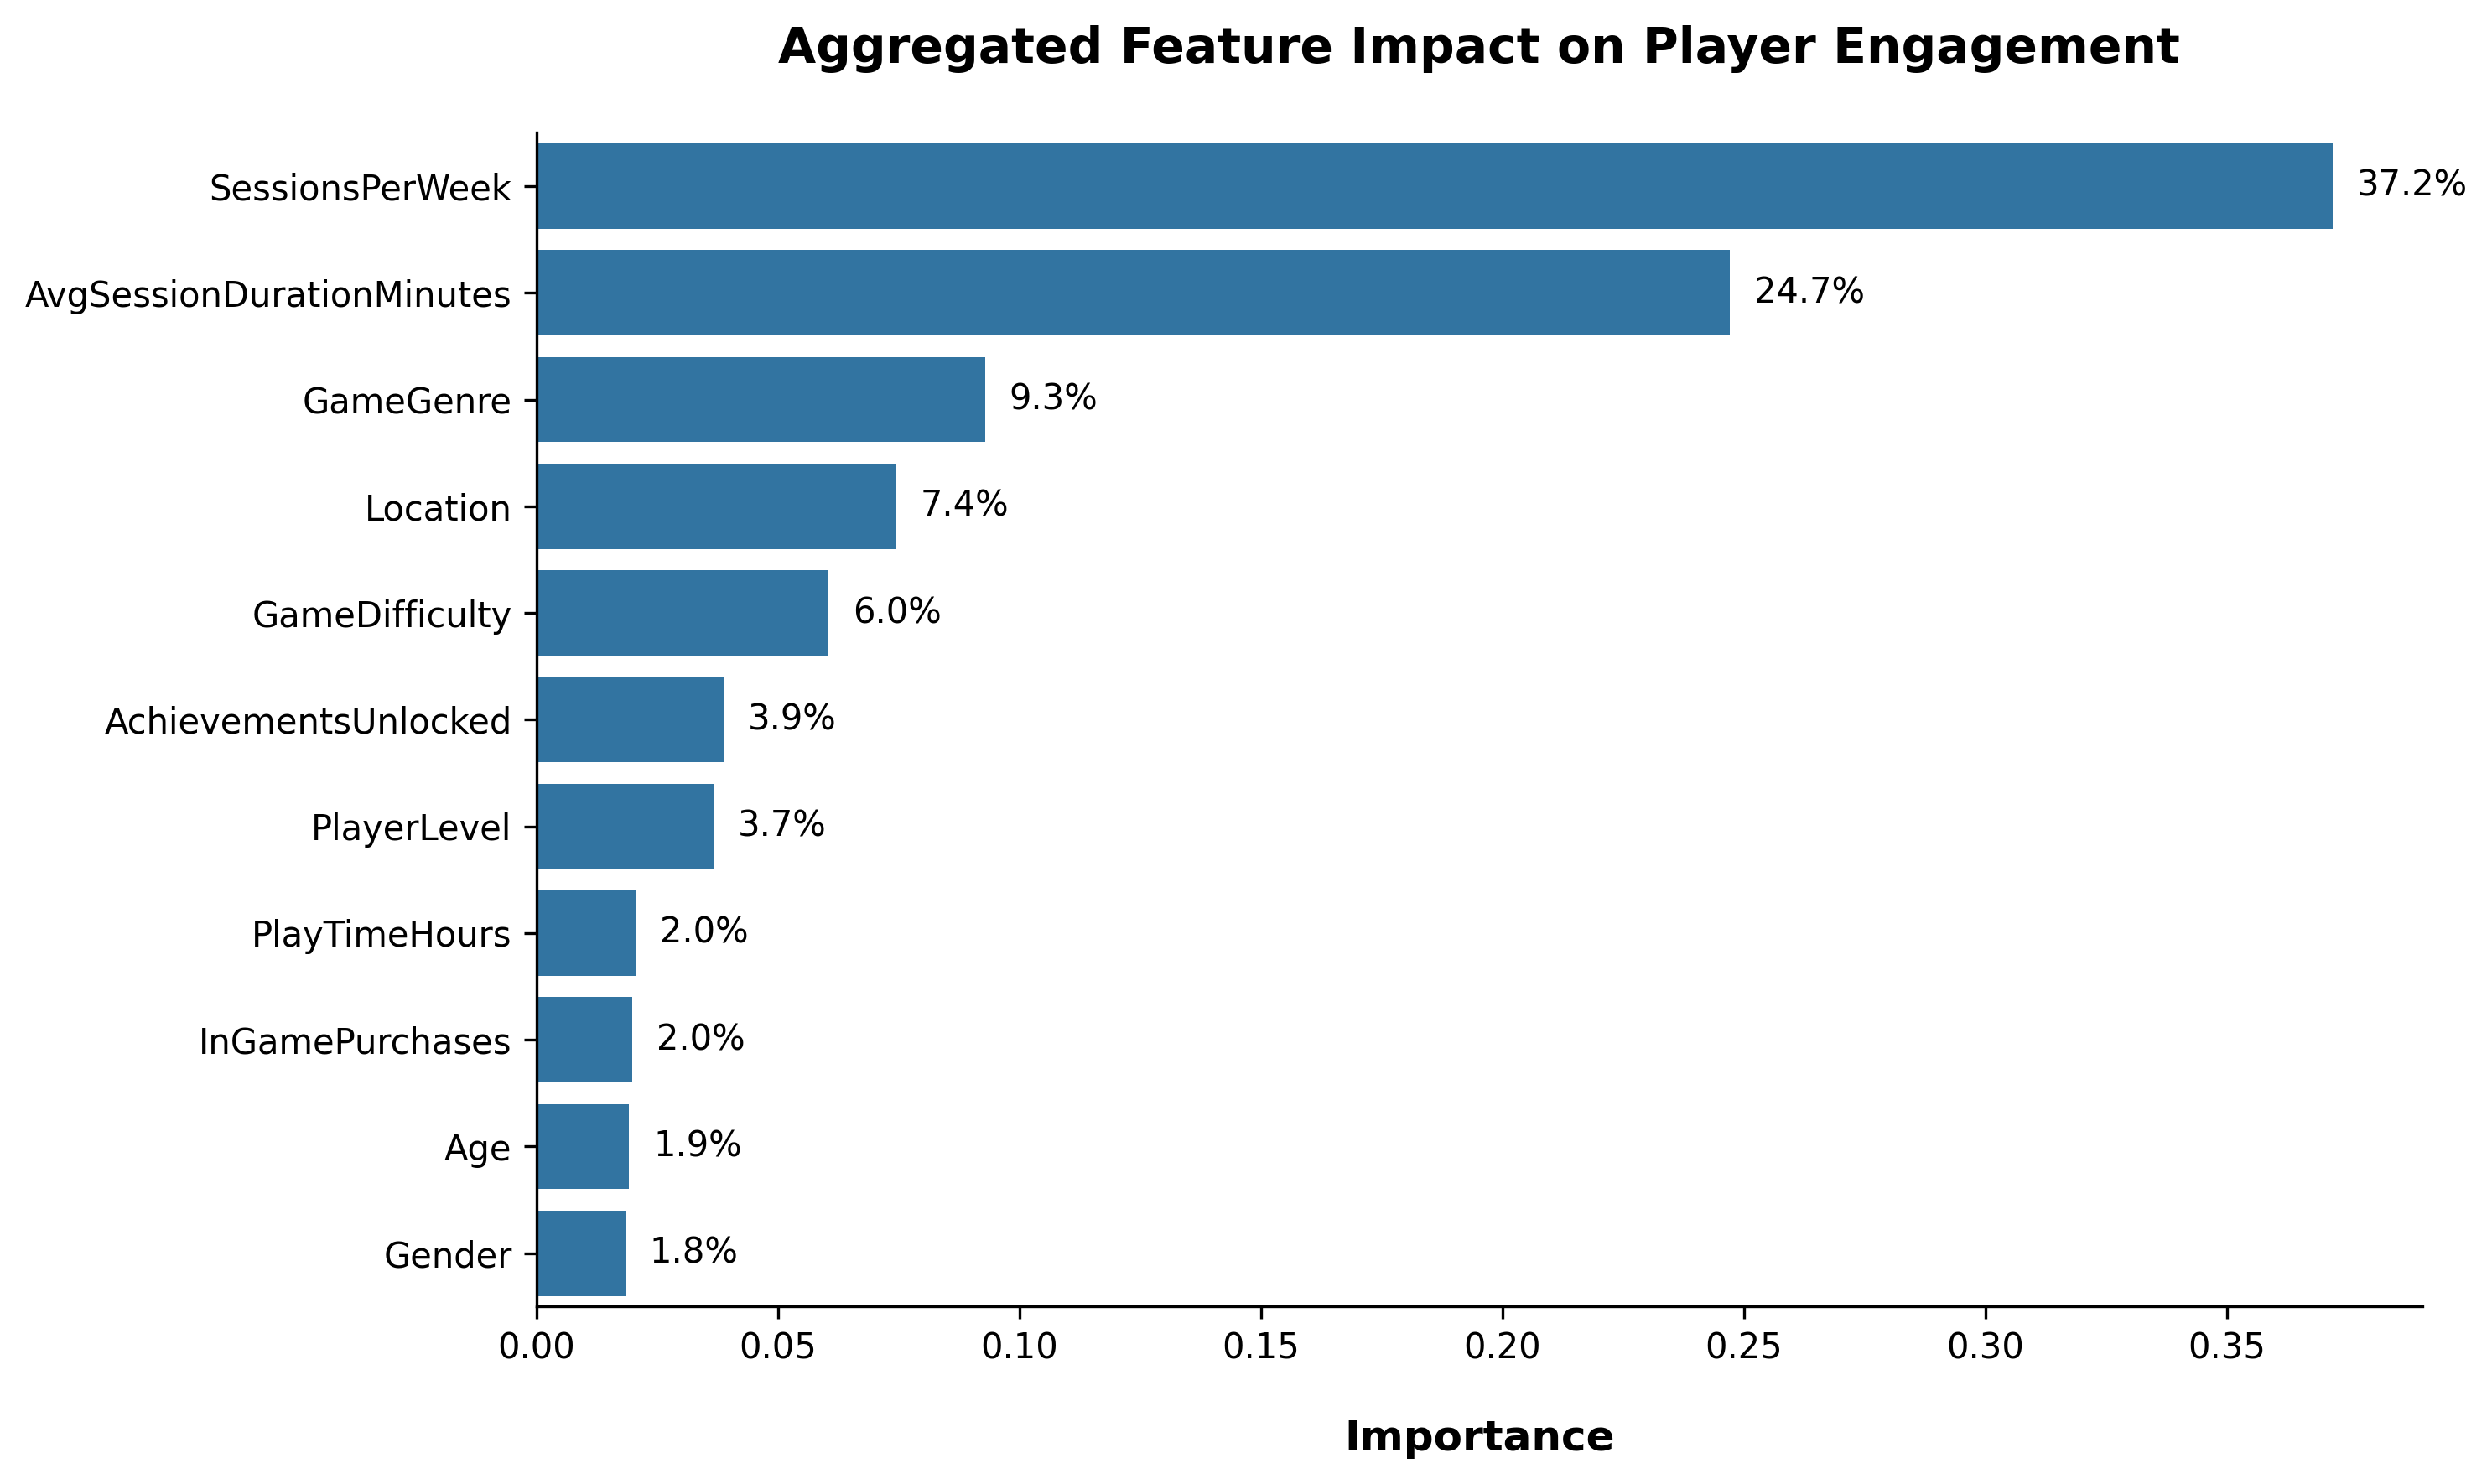

In [42]:
plt.figure(figsize=(10, 6))

# Plotting the Parent Features
sns.barplot(data= parent_feature_imp,
            x= 'Importance',
            y= 'ParentFeature')

# Add percentage labels to the bars
for i, v in enumerate(parent_feature_imp['Importance']):
    plt.text(v + 0.005, i, f'{v*100:.1f}%', va= 'center')

plt.title(f"Aggregated Feature Impact on Player Engagement", pad= 20)
plt.xlabel('Importance', weight='semibold', labelpad= 15)
plt.ylabel('')

plt.tight_layout()

# save image  
plt.savefig('../reports/figures/modeling/final_model_feature_importance.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

#### **5. Compare Baseline vs Tuned Performance**

In [43]:
# compare baseline and tuned model performance
baseline_cv_f1 = baseline_results_df.loc[baseline_results_df['Model'] == best_tuned_model_name,
                                            'CV Macro F1-Score'].values[0]
tuned_cv_f1 = tuned_result_df.iloc[0]['Best CV F1']
tuned_test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("=" * 40)
print(f"{best_tuned_model_name} Performance Comparison: Macro F1")
print("=" * 40)

print(f"Baseline CV F1   : {baseline_cv_f1:.4f}")
print(f"Tuned CV F1      : {tuned_cv_f1:.4f}")
print(f"Tuned Test F1    : {tuned_test_f1:.4f}")
print(f"Improvement      : {tuned_test_f1 - baseline_cv_f1:.4f}")

XGBoost Performance Comparison: Macro F1
Baseline CV F1   : 0.9079
Tuned CV F1      : 0.9122
Tuned Test F1    : 0.9120
Improvement      : 0.0042


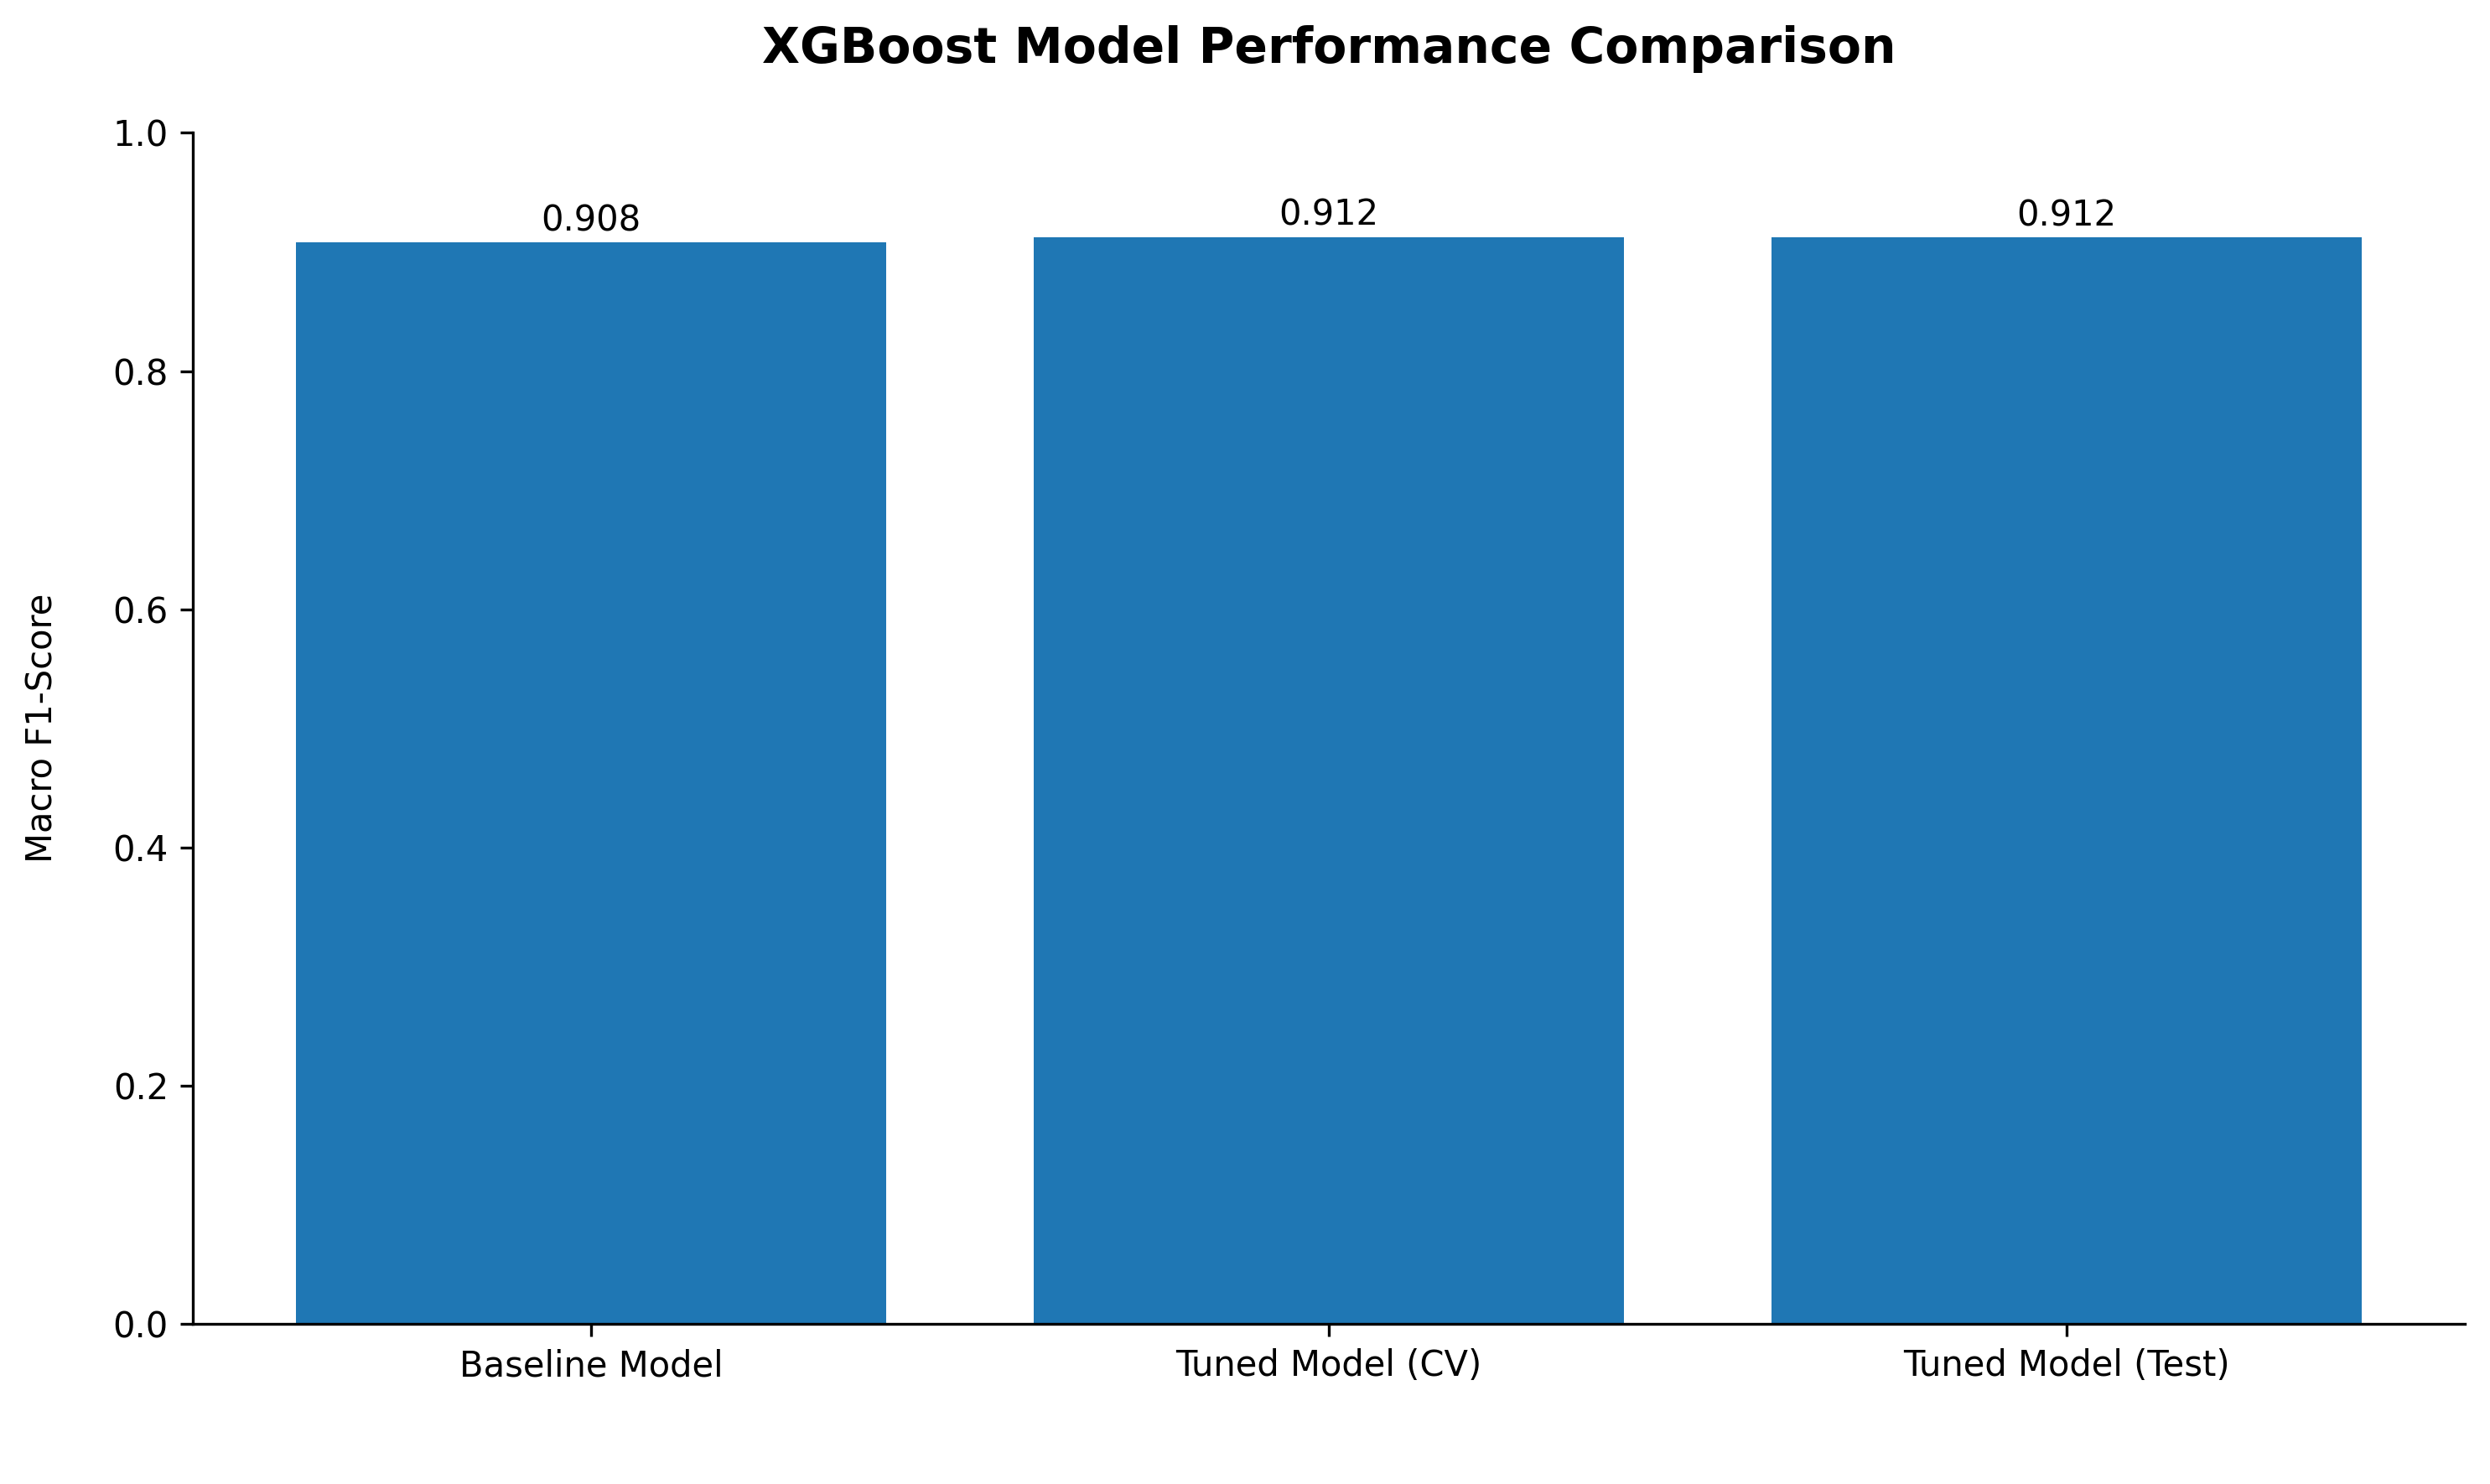

In [44]:
scores = [baseline_cv_f1, tuned_cv_f1, tuned_test_f1]
labels = ['Baseline Model', 'Tuned Model (CV)', 'Tuned Model (Test)']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, scores)

plt.title(f'{best_tuned_model_name} Model Performance Comparison', pad=20)
plt.ylabel('Macro F1-Score', fontsize= 10, labelpad= 15)
plt.xlabel(' ', labelpad=10)
plt.ylim(0, 1)

# add percentage labels  
for bar, score in zip(bars, scores):
    plt.text(x= bar.get_x() + bar.get_width()/2, 
             y= score + 0.01,
             s= f'{score:.3f}',
             ha= 'center')

plt.tight_layout()

# save image  
plt.savefig('../reports/figures/modeling/model_performance_comparison.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

#### **6. Generalization / Overfitting Check**

In [45]:
# calculate the difference between test and train
generalization_gap  = tuned_cv_f1 - tuned_test_f1

# Display the results in a clean comparison
print("="*40)
print(f"OVERFITTING CHECK : {best_tuned_model_name}")
print("="*40)

print(f"Train Score (CV)   : {tuned_cv_f1:.4f}")
print(f"Test Score (Final) : {tuned_test_f1:.4f}")
print(f"Generalization Gap : {generalization_gap :.4f}")
print("="*40)

if generalization_gap  > 0.05:
        print("Warning: Potential Overfitting (Gap > 5%)")
else: 
    print("Success: Model Generalizes Well (Low Gap)")        

OVERFITTING CHECK : XGBoost
Train Score (CV)   : 0.9122
Test Score (Final) : 0.9120
Generalization Gap : 0.0002
Success: Model Generalizes Well (Low Gap)


### **Error Analysis and Misclassification Insights**

#### **1. Test Set Error Summary**

In [46]:
# Create Test Set Predictions DataFrame
test_pred_df = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_test_pred}, index= X_test.index)

# Decode numeric labels back to original class names
test_pred_df['Actual_Label'] = [class_names[i] for i in y_test]
test_pred_df['Predicted_Label'] = [class_names[i] for i in y_test_pred]

# Misclassified samples
misclassified_df = test_pred_df[test_pred_df['Actual'] != test_pred_df['Predicted']]

error_rate = len(misclassified_df) * 100 / len(test_pred_df)

print(f"{'='*40}")
print(f"Error Analysis - {best_tuned_model_name}".center(40))
print(f"{'='*40}")

print(f"Total Test Samples     : {len(test_pred_df)}")
print(f"Misclassified Samples  : {len(misclassified_df)}")
print(f"Overall Error Rate (%) : {error_rate:.2f}")

        Error Analysis - XGBoost        
Total Test Samples     : 10009
Misclassified Samples  : 835
Overall Error Rate (%) : 8.34


#### **2. Missclassification Ratios**

In [47]:
misclassification_ratio = pd.crosstab(
    misclassified_df['Actual_Label'],
    misclassified_df['Predicted_Label'],
    rownames= ['Actual'],
    colnames= ['Predicted'],
    normalize= True
)

# reorder rows and columns
misclassification_ratio = misclassification_ratio.reindex(
    index=class_names,
    columns=class_names
)
print(misclassification_ratio)

Predicted       Low    Medium      High
Actual                                 
Low        0.000000  0.269461  0.087425
Medium     0.154491  0.000000  0.125749
High       0.092216  0.270659  0.000000


#### **3. Most Common Error Type**

In [48]:
# identify the most frequent misclassification type
# defensive check prevents errors if the model makes zero mistakes

if len(misclassified_df) > 0:

    most_common_error = (misclassified_df.value_counts(['Actual_Label', 'Predicted_Label']).
                         reset_index(name='Count').iloc[0])

    print(f"Most Common Error: "
          f"{most_common_error['Actual_Label']} → "
          f"{most_common_error['Predicted_Label']} "
          f"({most_common_error['Count']} Samples)")
else:
    print("No misclassifications found.")

Most Common Error: High → Medium (226 Samples)


#### **4. Average Behavior Per Actual Class**

In [49]:
# AVERAGE BEHAVIOR PER ACTUAL CLASS (TEST SET)

# create a copy of test set and attach actual class labels
actual_test_df = X_test.copy()
actual_test_df['Actual'] = [class_names[i] for i in y_test]

# key behavioral features
behavior_cols = ['SessionsPerWeek', 'AvgSessionDurationMinutes']

# compute class-wise behavioral averages
actual_class_avg = (actual_test_df.groupby('Actual')[behavior_cols].mean().round(2))

# reorder rows to match class_names
actual_class_avg = actual_class_avg.reindex(class_names)

# display the actual class averages
print("Actual Class Average Behavior (Test Set)")
display(actual_class_avg)

Actual Class Average Behavior (Test Set)


,SessionsPerWeek,AvgSessionDurationMinutes
Actual,,
Low,4.59,65.96
Medium,9.53,90.07
High,14.32,131.43


#### **5. Missclassified Behavior Analysis**

In [50]:
# MISCLASSIFIED BEHAVIOR vs ACTUAL CLASS AVERAGE (DEVIATION)

# extract only misclassified test samples
test_error_df = X_test.loc[y_test != y_test_pred].copy()

# attach true and predicted engagement labels
test_error_df['Actual'] = [class_names[i] for i in y_test[y_test != y_test_pred]]
test_error_df['Predicted'] = [class_names[i] for i in y_test_pred[y_test != y_test_pred]]

# compute average behavioral metrics for each (Actual → Predicted) error type
misclassified_avg_df = (test_error_df.groupby(['Actual', 'Predicted'])[behavior_cols].mean().round(2))

# calculate session frequency difference from true class average
misclassified_avg_df['Session_Diff'] = (
    misclassified_avg_df['SessionsPerWeek'] - misclassified_avg_df.index.get_level_values('Actual').map(
        actual_class_avg['SessionsPerWeek']
    )
)

# calculate session duration difference from true class average
misclassified_avg_df['Duration_Diff'] = (
    misclassified_avg_df['AvgSessionDurationMinutes'] - misclassified_avg_df.index.get_level_values('Actual').map(
        actual_class_avg['AvgSessionDurationMinutes']
    )
)

# sort by class order
misclassified_avg_df = misclassified_avg_df.sort_index(
    level=[0, 1],
    key=lambda x: x.map({c: i for i, c in enumerate(class_names)})
)

# display misclassification behavior deviations
display(misclassified_avg_df)

SessionsPerWeek  AvgSessionDurationMinutes  Session_Diff  \
Actual Predicted                                                             
Low    Medium                9.02                      81.37          4.43   
       High                 15.11                     134.74         10.52   
Medium Low                   4.62                      68.29         -4.91   
       High                 13.94                     133.49          4.41   
High   Low                   3.48                      68.30        -10.84   
       Medium               10.92                      90.08         -3.40   

                  Duration_Diff  
Actual Predicted                 
Low    Medium             15.41  
       High               68.78  
Medium Low               -21.78  
       High               43.42  
High   Low               -63.13  
       Medium            -41.35

##### **Visualization of Behavioral Deviations**


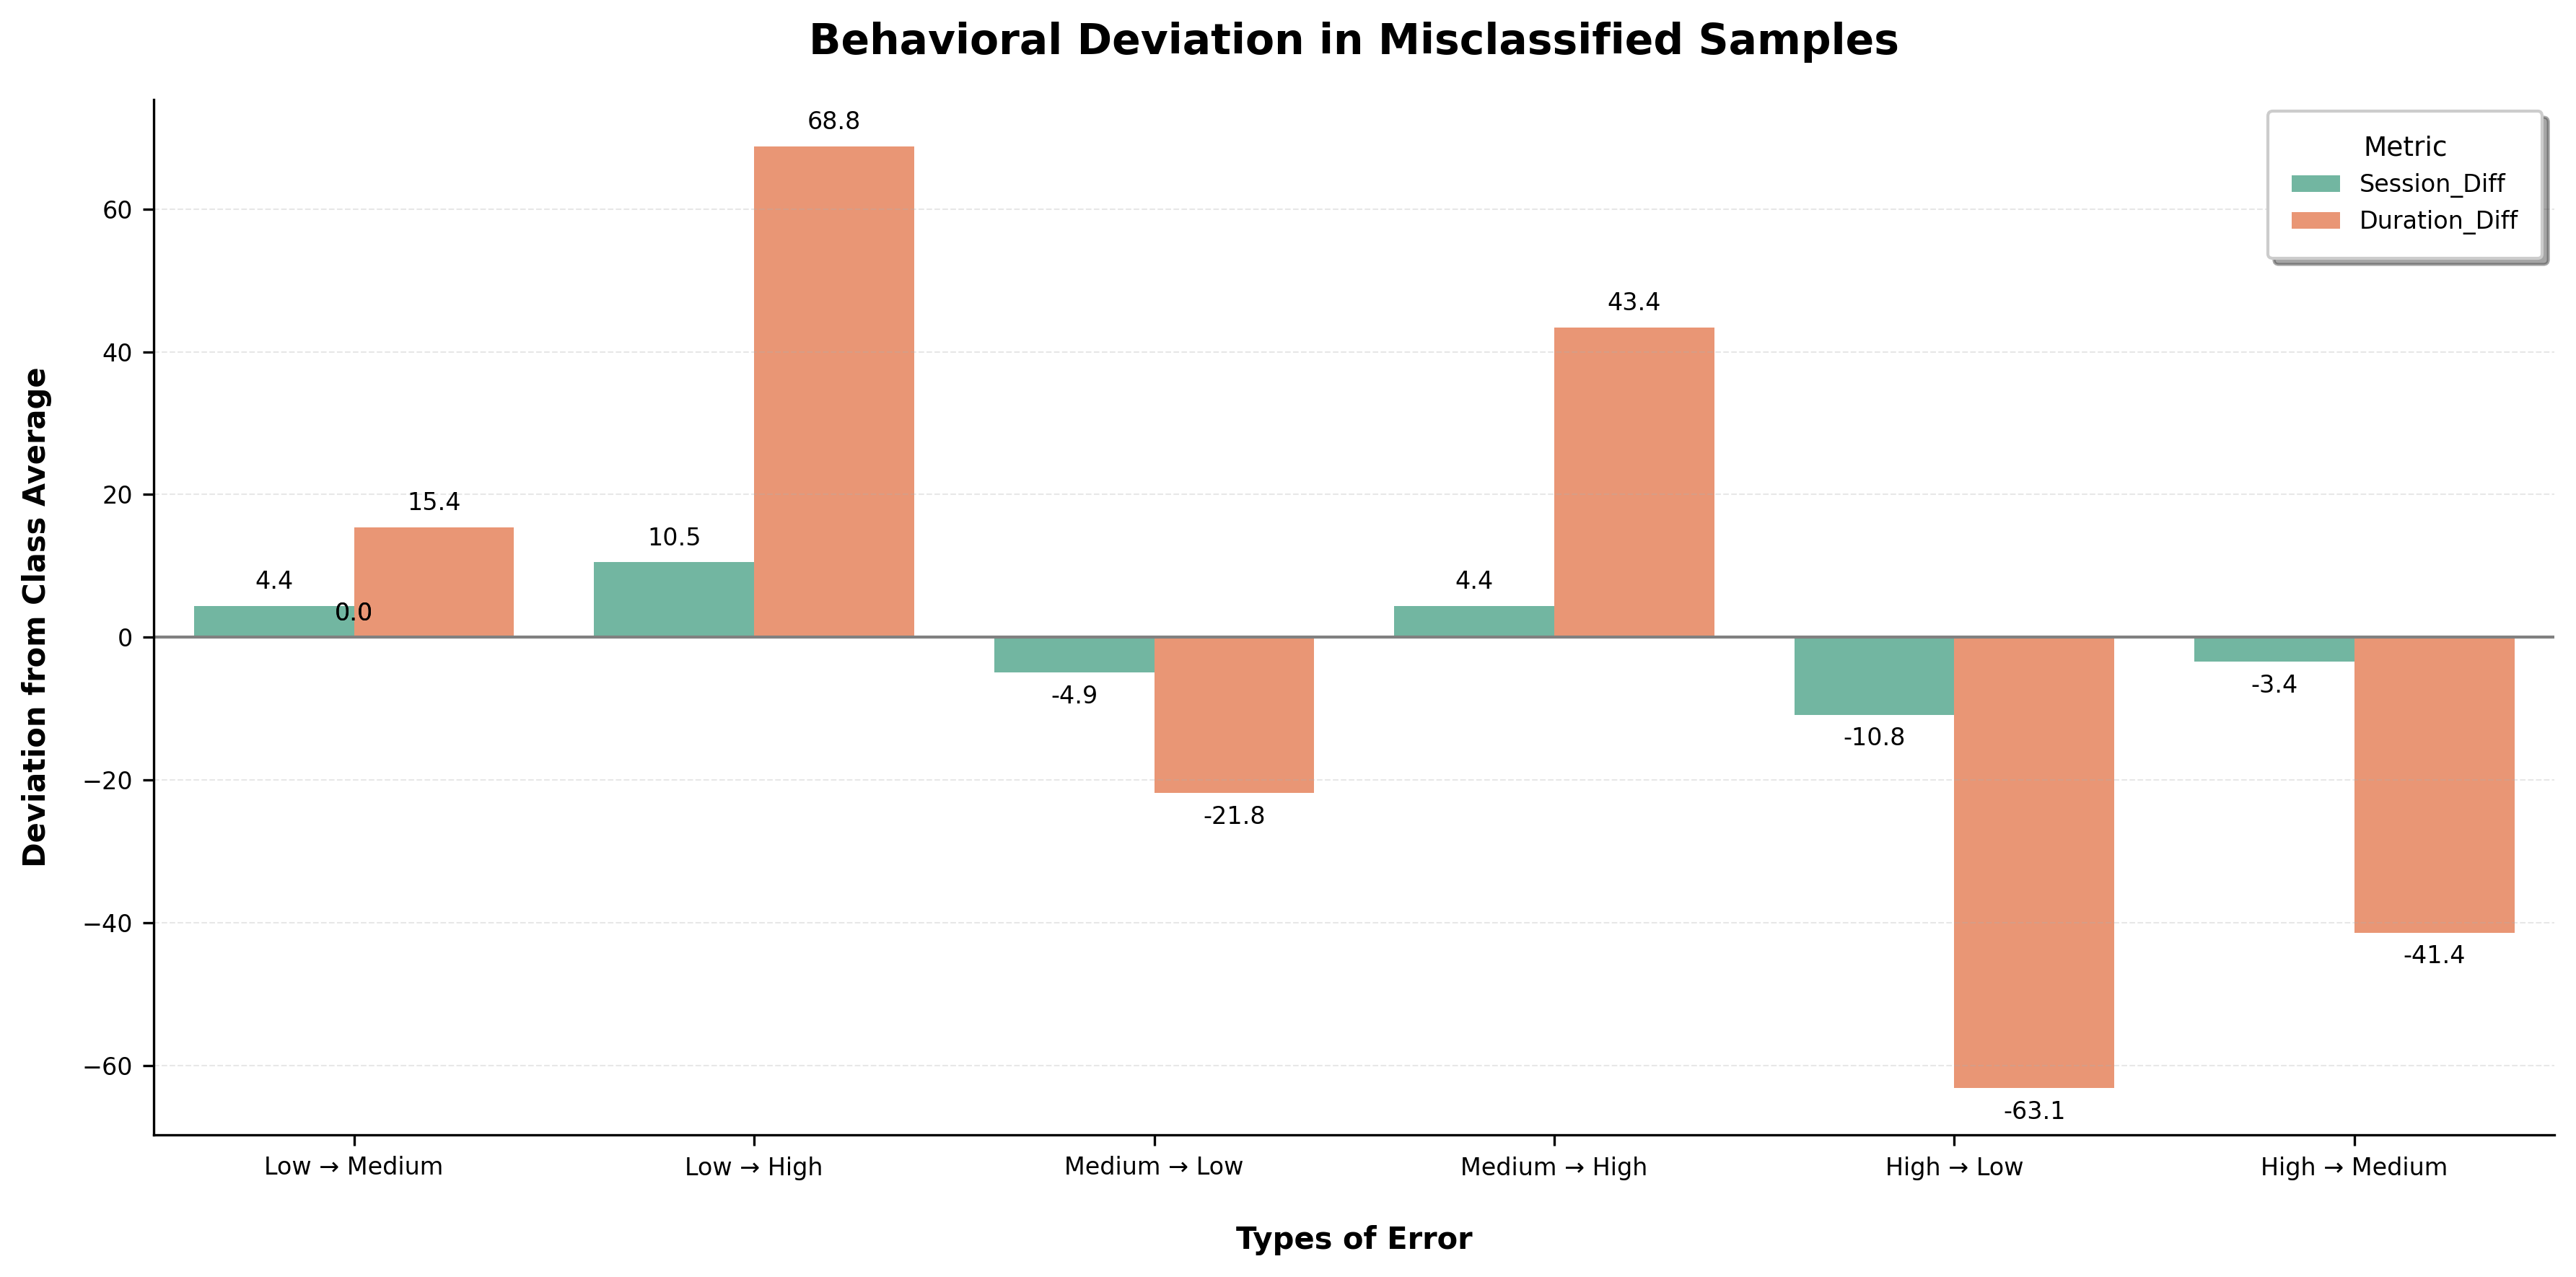

In [51]:
# Prepare data for plotting
plot_df = misclassified_avg_df.reset_index()
plot_df['Error'] = plot_df['Actual'] + ' → ' + plot_df['Predicted']
plot_df = plot_df.melt(id_vars='Error', value_vars=['Session_Diff', 'Duration_Diff'], 
                  var_name='Metric', value_name='Deviation')

# Create bar plot of behavioral deviation by error type
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data= plot_df, x= 'Error', y= 'Deviation', hue= 'Metric', palette='Set2', ax= ax)

# Add reference line and subtle grid
ax.axhline(y= 0, color="gray", linewidth= 1)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth= 0.5)

# Set titles and labels
ax.set_title('Behavioral Deviation in Misclassified Samples')
ax.set_xlabel('Types of Error', weight='semibold', size=10, labelpad= 15)
ax.set_ylabel('Deviation from Class Average', weight= 'semibold', size= 10, labelpad= 10)

# Configure legend
ax.legend(title='Metric', title_fontsize=9, fontsize=8,
          frameon= True, shadow= True, borderpad=1, loc='upper right')

# Add value labels to bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom' if p.get_height() >= 0 else 'top',
        xytext=(0, 4 if p.get_height() >= 0 else -4),
        textcoords='offset points',
        fontsize=8
    )

plt.xticks(size= 8)
plt.yticks(size= 8)

plt.tight_layout()
sns.despine()

# save image  
plt.savefig('../reports/figures/modeling/misclassification_behavior.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

**Insight:**  
Misclassified samples show clear deviations in session frequency and session duration from their true class averages, indicating that borderline behavioral patterns contribute to prediction errors.

### **Saving the Trained Model and Encoders**

In [ ]:
import joblib
from pathlib import Path

# get project root directory safely
BASE_DIR = Path().resolve().parent  # if running inside notebooks/

# if your notebook is inside /notebooks, go one level up
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# define models directory
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# SAVE TRAINED MODEL
model_path = MODELS_DIR / f"{best_tuned_model_name.lower().replace(' ', '_')}_pipeline.joblib"

joblib.dump(best_tuned_model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: C:\dev\ml-projects\gaming-engagement-ml\models\xgboost_pipeline.joblib


In [ ]:
# SAVE LABEL MAPPING
label_mapping_path = MODELS_DIR / "label_mapping.joblib"

joblib.dump(label_mapping, label_mapping_path)

print(f"Label mapping saved successfully at: {label_mapping_path}")

Label mapping saved successfully at: C:\dev\ml-projects\gaming-engagement-ml\models\label_mapping.joblib
